# Intersubject representational similarity — simple first pass

This notebook asks three deliberately narrow questions in each Tavares ROI:

1. **Shared task representation:** does each participant's neural representational geometry resemble the leave-one-participant-out group geometry?
2. **Choice-specific representation:** do pairs of participants with more similar choice geometries also have more similar neural geometries?
3. **Individual differences:** which participants align more or less strongly with the choice–neural relationship across their partners?
4. **Matched choice specificity:** does neural geometry track the chosen option more strongly than the simultaneously presented unchosen option?
5. **Constrained robustness:** does choice-linked neural alignment survive removal of participant-level typicality and reproduce within each diagnostic group?
6. **External-person decomposition:** how much unique neural-similarity variance is associated with choices, subjective social maps, stable traits, quality/engagement, and demographic/design similarity?

All dyadic tests use participant-label permutations rather than treating dyads as independent. These analyses quantify **representational alignment** and blockwise statistical variance, not a literal decomposition of neural activity into shared and private biological components.

In [1]:
import importlib
import sys
import types
from pathlib import Path

# Locate this repository's code directory before importing shared.main.
# This prevents an older `shared` package cached by an IPython startup file
# from silently supplying a different project configuration.
search_roots = [Path.cwd(), *Path.cwd().parents, Path.home() / 'Projects' / 'SocialCUD']
SOCIALCUD_CODE_DIR = next((
    candidate / 'code' for candidate in search_roots
    if (candidate / 'code' / 'shared' / 'main.py').exists()
), None)
if SOCIALCUD_CODE_DIR is None:
    raise FileNotFoundError('Could not locate SocialCUD/code/shared/main.py.')
sys.path.insert(0, str(SOCIALCUD_CODE_DIR))
for module_name in list(sys.modules):
    if module_name == 'shared' or module_name.startswith('shared.'):
        del sys.modules[module_name]
shared_package = types.ModuleType('shared')
shared_package.__path__ = [str(SOCIALCUD_CODE_DIR / 'shared')]
shared_package.__package__ = 'shared'
sys.modules['shared'] = shared_package

from shared.main import *
shared_main = importlib.import_module('shared.main')
assert Path(shared_main.__file__).resolve() == (SOCIALCUD_CODE_DIR / 'shared' / 'main.py').resolve()
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr

TAVARES_ROIS = [
    'HPC-L', 'HPC-R', 'DLPFC-L', 'DLPFC-R',
    'dACC-L', 'dACC-R', 'PCC-R', 'PCC-L',
]
MIN_VOXELS = 5
N_QAP_PERMUTATIONS = 1_000  # Development default; use >=10,000 for final results.
N_SUBJECT_PERMUTATIONS = 10_000
RANDOM_SEED = 20260814
GROUP_PALETTE = {'HC': '#1F77B4', 'CD': '#D62728'}

# Same input and ROI definitions used in rsa_roi_v3.ipynb.
subject_data = shared_main.load_pickle(
    f'{shared_main.data_dir}/../results/glms/lss_decision/subject_data_Tavares.pkl'
)
rois = TAVARES_ROIS.copy()

print(f'Loaded {len(subject_data)} participants and {len(rois)} Tavares ROIs.')

Loaded 67 participants and 8 Tavares ROIs.


## Representational distances and task controls

Each participant contributes one trial-by-trial representational dissimilarity vector (RDV) per ROI and one RDV for the semantic content of their choices. Neural distance is correlation distance between multivoxel trial patterns; choice distance is cosine distance between choice-text embeddings.

For the choice-specific analysis, both neural and choice RDVs are residualized within participant for a small prespecified set of shared task features: absolute trial separation (linear and quadratic), decision dimension, character identity, and within-character trial separation. This makes the dyadic effect harder to explain as two participants simply sharing the same task schedule. The raw neural RDV is retained for the basic sharedness estimate.

In [2]:
def clean_roi_betas(X, min_voxels=MIN_VOXELS):
    """Drop unusable voxels while preserving the trial axis."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        return None
    X = X[:, np.isfinite(X).all(axis=0)]
    if X.shape[1] > 0:
        X = X[:, np.nanstd(X, axis=0) > 0]
    if X.shape[1] < min_voxels:
        return None
    return X


def safe_zscore(x):
    x = np.asarray(x, dtype=float)
    scale = np.nanstd(x, ddof=0)
    if not np.isfinite(scale) or scale == 0:
        raise ValueError('Cannot standardize a constant or non-finite vector.')
    return (x - np.nanmean(x)) / scale


def neural_rdv(roi_betas):
    X = clean_roi_betas(roi_betas)
    if X is None:
        return None
    return pdist(X, metric='correlation')

def choice_rdv(choice_embeddings):
    X = np.asarray(choice_embeddings, dtype=float)
    if X.ndim != 2 or not np.isfinite(X).all():
        return None
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    if np.any(norms == 0):
        return None
    return pdist(X / norms, metric='cosine')


def task_control_rdvs(behavior, pair_i, pair_j):
    trial = behavior['decision_num'].to_numpy(dtype=float)
    within_character = behavior['character_decision_num'].to_numpy(dtype=float)
    dimension = pd.factorize(behavior['dimension'], sort=True)[0]
    character = pd.factorize(behavior['character_role_num'], sort=True)[0]

    trial_distance = np.abs(trial[pair_i] - trial[pair_j])
    return pd.DataFrame({
        'trial_distance': trial_distance,
        'trial_distance_sq': trial_distance ** 2,
        'different_dimension': (dimension[pair_i] != dimension[pair_j]).astype(float),
        'different_character': (character[pair_i] != character[pair_j]).astype(float),
        'within_character_distance': np.abs(
            within_character[pair_i] - within_character[pair_j]
        ),
    })


def residualize_rdv(target, controls, mask):
    """Residualize and standardize one RDV on the specified valid pairs."""
    y = safe_zscore(np.asarray(target, dtype=float)[mask])
    X_columns = []
    for column in controls.columns:
        x = controls[column].to_numpy(dtype=float)[mask]
        if np.nanstd(x, ddof=0) > 0:
            X_columns.append(safe_zscore(x))
    X = np.column_stack([np.ones(y.size), *X_columns])
    residual = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    return safe_zscore(residual)


def row_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(pearsonr(x, y)[0])


def fisher_z(r):
    return np.arctanh(np.clip(r, -0.999999, 0.999999))


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order] * len(p_values) / np.arange(1, len(p_values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted


def sharedness_sign_flip_test(subject_by_pair_matrix, n_permutations, rng):
    """Flip whole participant RDVs and recompute mean leave-one-out sharedness."""
    correlation = np.corrcoef(subject_by_pair_matrix)
    n_subjects = correlation.shape[0]
    diagonal = np.diag(correlation)

    def mean_sharedness(signs):
        signs = np.atleast_2d(signs)
        signed_row_sums = signs * (signs @ correlation)
        total_sum = signed_row_sums.sum(axis=1, keepdims=True)
        numerator = (signed_row_sums - diagonal) / (n_subjects - 1)
        template_variance = (
            total_sum - 2 * signed_row_sums + diagonal
        ) / (n_subjects - 1) ** 2
        r = numerator / np.sqrt(np.clip(template_variance, 1e-12, None))
        return fisher_z(r).mean(axis=1)

    observed = mean_sharedness(np.ones(n_subjects))[0]
    random_signs = rng.choice(
        [-1.0, 1.0], size=(n_permutations, n_subjects)
    )
    null = mean_sharedness(random_signs)
    p_value = (1 + np.sum(np.abs(null) >= abs(observed))) / (n_permutations + 1)
    return observed, p_value


def label_permutation_group_test(values, groups, n_permutations, rng):
    """Two-sided CD-minus-HC mean difference under participant-label exchangeability."""
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)
    keep = np.isfinite(values) & np.isin(groups, ['HC', 'CD'])
    values, groups = values[keep], groups[keep]
    observed = values[groups == 'CD'].mean() - values[groups == 'HC'].mean()
    null = np.empty(n_permutations, dtype=float)
    for permutation_index in range(n_permutations):
        permuted_groups = rng.permutation(groups)
        null[permutation_index] = (
            values[permuted_groups == 'CD'].mean()
            - values[permuted_groups == 'HC'].mean()
        )
    p_value = (1 + np.sum(np.abs(null) >= abs(observed))) / (n_permutations + 1)
    return observed, p_value


def significance_stars(q_value):
    if q_value < 0.001:
        return '***'
    if q_value < 0.01:
        return '**'
    if q_value < 0.05:
        return '*'
    return ''


def add_significance_bracket(ax, x_left, x_right, y, stars, height):
    if not stars:
        return
    ax.plot(
        [x_left, x_left, x_right, x_right],
        [y, y + height, y + height, y],
        color='black', linewidth=1, clip_on=False,
    )
    ax.text((x_left + x_right) / 2, y + height, stars, ha='center', va='bottom')

In [3]:
def build_subject_rdvs(subject_data, rois):
    """Create aligned choice, task-control, and neural RDVs for all participants."""
    subject_ids = sorted(subject_data)
    required_design_columns = [
        'decision_num', 'dimension', 'character_role_num', 'character_decision_num'
    ]
    reference_behavior = subject_data[subject_ids[0]]['behavior'].reset_index(drop=True)
    n_trials = len(reference_behavior)
    pair_i, pair_j = np.triu_indices(n_trials, k=1)
    records = []

    for subject_id in subject_ids:
        subject = subject_data[subject_id]
        behavior = subject['behavior'].reset_index(drop=True)
        if len(behavior) != n_trials:
            raise ValueError(f'{subject_id} has {len(behavior)} trials; expected {n_trials}.')

        # Cross-participant RDM entries are only comparable if trial-pair meanings align.
        for column in required_design_columns:
            if not behavior[column].equals(reference_behavior[column]):
                raise ValueError(f'Task sequence differs for {subject_id}: {column}.')

        choice = choice_rdv(subject['embeddings']['choice'])
        controls = task_control_rdvs(behavior, pair_i, pair_j)
        neural = {roi: neural_rdv(subject['roi_betas'].get(roi)) for roi in rois}
        if choice is None or any(neural[roi] is None for roi in rois):
            print(f'Skipping {subject_id}: unusable choice embeddings or ROI data.')
            continue

        records.append({
            'sub_id': subject_id,
            'choice': choice,
            'controls': controls,
            'neural': neural,
        })

    return records, (pair_i, pair_j)


def prepare_roi_matrices(records, rois):
    """Return subject-by-trial-pair matrices on a common valid-pair mask per ROI."""
    matrices = {}
    for roi in rois:
        n_pairs = len(records[0]['choice'])
        common_mask = np.ones(n_pairs, dtype=bool)
        for record in records:
            common_mask &= np.isfinite(record['choice'])
            common_mask &= np.isfinite(record['neural'][roi])
            common_mask &= np.isfinite(record['controls'].to_numpy(dtype=float)).all(axis=1)

        if common_mask.sum() < 10:
            raise ValueError(f'{roi} has too few common trial pairs: {common_mask.sum()}.')

        matrices[roi] = {
            'mask': common_mask,
            'neural_raw': np.vstack([
                safe_zscore(record['neural'][roi][common_mask]) for record in records
            ]),
            'neural_resid': np.vstack([
                residualize_rdv(record['neural'][roi], record['controls'], common_mask)
                for record in records
            ]),
            'choice_resid': np.vstack([
                residualize_rdv(record['choice'], record['controls'], common_mask)
                for record in records
            ]),
        }
    return matrices


records, trial_pair_indices = build_subject_rdvs(subject_data, rois)
subject_ids = [record['sub_id'] for record in records]
roi_matrices = prepare_roi_matrices(records, rois)

metadata_columns = [
    column for column in ['sub_id', 'dx', 'ctq_score', 'sex', 'memory_mean', 'fd_mean']
    if column in shared_main.data.columns
]
participant_metadata = (
    shared_main.data[metadata_columns]
    .drop_duplicates('sub_id')
    .query('sub_id in @subject_ids')
    .copy()
)
participant_metadata['group'] = participant_metadata['dx'].map({0: 'HC', 1: 'CD'})
metadata_by_id = participant_metadata.set_index('sub_id')

pair_counts = {roi: int(roi_matrices[roi]['mask'].sum()) for roi in rois}
print(f'Analysis sample: {len(subject_ids)} participants × {len(rois)} ROIs.')
print(f'Common valid trial pairs per ROI: {pair_counts}')
display(participant_metadata.groupby('group', dropna=False).size().rename('N').to_frame())

Analysis sample: 67 participants × 8 ROIs.
Common valid trial pairs per ROI: {'HPC-L': 1953, 'HPC-R': 1953, 'DLPFC-L': 1953, 'DLPFC-R': 1953, 'dACC-L': 1953, 'dACC-R': 1953, 'PCC-R': 1953, 'PCC-L': 1953}


,N
group,
CD,31
HC,36


## 1. Shared task representations

For each participant and ROI, correlate that participant's neural RDV with the average RDV of all other participants. Fisher-z-transformed correlations are the sharedness scores. Leave-one-participant-out templates avoid correlating a participant with a group template that contains their own data.

- **Total neural geometry** asks whether task-evoked representational organization is shared overall.
- **After task controls** asks whether any alignment remains beyond the simple schedule features defined above.

These scores depend on reliable participant-level RDMs; they do not by themselves distinguish a weak idiosyncratic representation from noisy data. For visualization, bars show means ± participant-level SE and points show participants. For inference, a two-sided whole-participant sign-flip test multiplies each participant's complete RDV by +1 or −1 and recomputes the mean leave-one-out sharedness. This preserves the dependencies among trial pairs and among the overlapping leave-one-out templates. BH-FDR correction is applied across all 16 ROI × measure tests. Asterisks denote FDR-adjusted significance (* q < .05, ** q < .01, *** q < .001).

,roi,measure,mean,sd,N,se,mean_fisher_z,p_sign_flip,q_BH,stars
4,HPC-L,After task controls,0.0692,0.0419,67,0.0051,0.0692,0.0001,0.0001,***
5,HPC-L,Total neural geometry,0.0720,0.0422,67,0.0051,0.0720,0.0001,0.0001,***
6,HPC-R,After task controls,0.0693,0.0440,67,0.0054,0.0693,0.0001,0.0001,***
7,HPC-R,Total neural geometry,0.0728,0.0448,67,0.0055,0.0728,0.0001,0.0001,***
0,DLPFC-L,After task controls,0.0928,0.0529,67,0.0065,0.0928,0.0001,0.0001,***
1,DLPFC-L,Total neural geometry,0.0940,0.0542,67,0.0066,0.0940,0.0001,0.0001,***
2,DLPFC-R,After task controls,0.0903,0.0607,67,0.0074,0.0903,0.0001,0.0001,***
3,DLPFC-R,Total neural geometry,0.0907,0.0613,67,0.0075,0.0907,0.0001,0.0001,***
12,dACC-L,After task controls,0.1305,0.0914,67,0.0112,0.1305,0.0001,0.0001,***
13,dACC-L,Total neural geometry,0.1327,0.0935,67,0.0114,0.1327,0.0001,0.0001,***


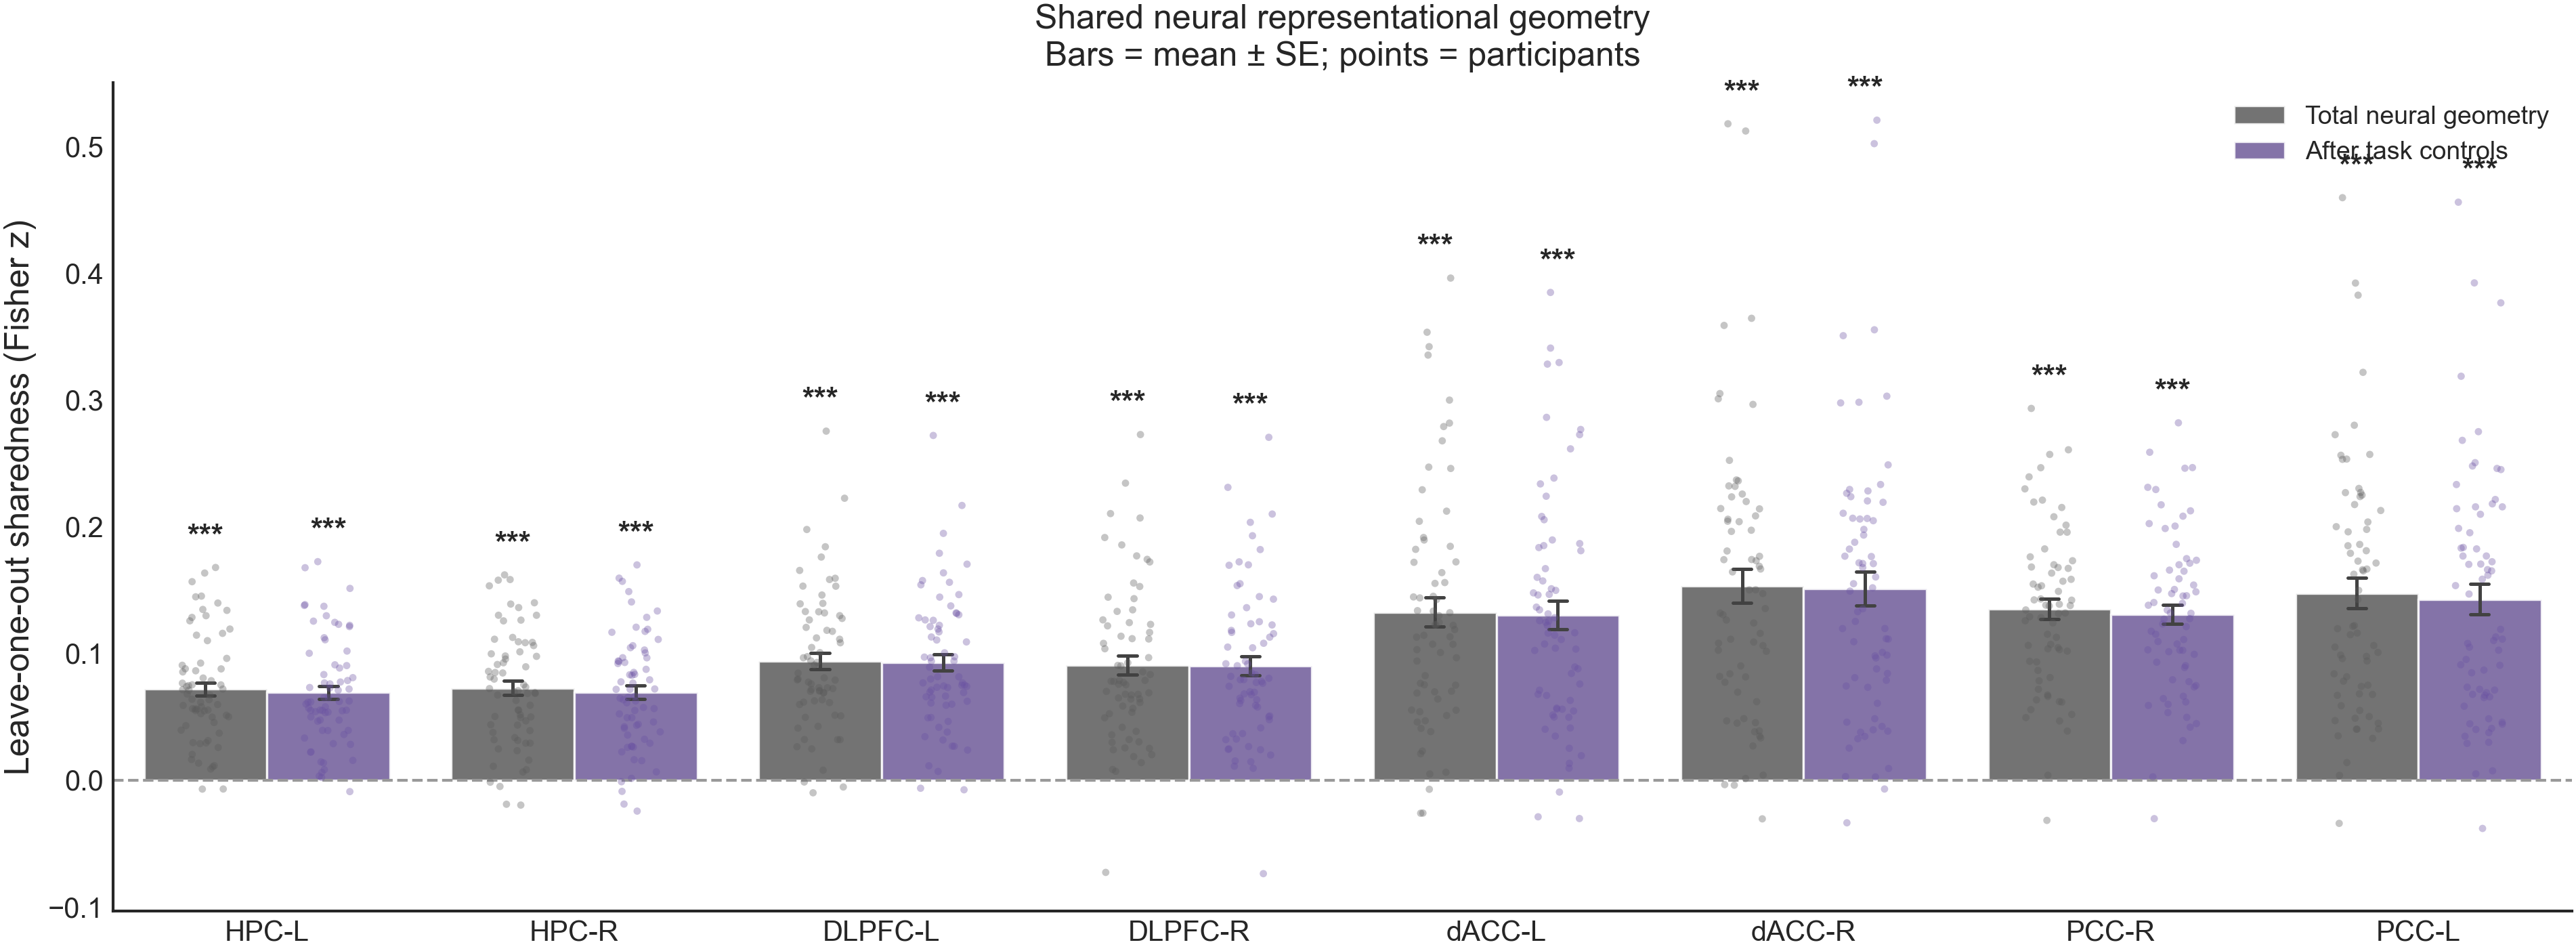

In [4]:
def leave_one_out_sharedness(subject_by_pair_matrix):
    scores = []
    for subject_index in range(subject_by_pair_matrix.shape[0]):
        keep = np.arange(subject_by_pair_matrix.shape[0]) != subject_index
        group_template = subject_by_pair_matrix[keep].mean(axis=0)
        r = row_correlation(subject_by_pair_matrix[subject_index], group_template)
        scores.append({'r': r, 'fisher_z': fisher_z(r)})
    return pd.DataFrame(scores)


sharedness_frames = []
sharedness_measures = {
    'Total neural geometry': 'neural_raw',
    'After task controls': 'neural_resid',
}
for roi in rois:
    for measure_label, matrix_key in sharedness_measures.items():
        frame = leave_one_out_sharedness(roi_matrices[roi][matrix_key])
        frame['sub_id'] = subject_ids
        frame['roi'] = roi
        frame['measure'] = measure_label
        sharedness_frames.append(frame)

sharedness = pd.concat(sharedness_frames, ignore_index=True).merge(
    participant_metadata, on='sub_id', how='left'
)
sharedness_summary = (
    sharedness.groupby(['roi', 'measure'], observed=True)['fisher_z']
    .agg(mean='mean', sd='std', N='count')
    .reset_index()
)
sharedness_summary['se'] = sharedness_summary['sd'] / np.sqrt(sharedness_summary['N'])

subject_rng = np.random.default_rng(RANDOM_SEED + 1)
sharedness_test_rows = []
for roi in rois:
    for measure, matrix_key in sharedness_measures.items():
        observed, p_value = sharedness_sign_flip_test(
            roi_matrices[roi][matrix_key],
            N_SUBJECT_PERMUTATIONS, subject_rng,
        )
        sharedness_test_rows.append({
            'roi': roi, 'measure': measure, 'mean_fisher_z': observed,
            'p_sign_flip': p_value,
        })
sharedness_tests = pd.DataFrame(sharedness_test_rows)
sharedness_tests['q_BH'] = benjamini_hochberg(sharedness_tests['p_sign_flip'])
sharedness_tests['stars'] = sharedness_tests['q_BH'].map(significance_stars)

sharedness_summary = sharedness_summary.merge(
    sharedness_tests, on=['roi', 'measure'], how='left'
)
sharedness_summary['roi'] = pd.Categorical(
    sharedness_summary['roi'], categories=rois, ordered=True
)
sharedness_summary = sharedness_summary.sort_values(['roi', 'measure'])
display(sharedness_summary.round(4))

measure_order = list(sharedness_measures)
measure_palette = {
    'Total neural geometry': '#5B5B5B',
    'After task controls': '#6A51A3',
}
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=sharedness, x='roi', y='fisher_z', hue='measure',
    order=rois, hue_order=measure_order, palette=measure_palette,
    errorbar='se', capsize=0.12, err_kws={'linewidth': 1.2},
    alpha=0.85, ax=ax,
)
sns.stripplot(
    data=sharedness, x='roi', y='fisher_z', hue='measure',
    order=rois, hue_order=measure_order, palette=measure_palette,
    dodge=True, jitter=0.16, size=2.6, alpha=0.35,
    linewidth=0, legend=False, ax=ax,
)

y_span = np.ptp(sharedness['fisher_z'].dropna())
star_pad = max(0.02 * y_span, 0.003)
bar_offsets = np.linspace(-0.2, 0.2, len(measure_order))
star_tops = []
for roi_index, roi in enumerate(rois):
    for measure_index, measure in enumerate(measure_order):
        test = sharedness_tests.query('roi == @roi and measure == @measure').iloc[0]
        if not test['stars']:
            continue
        values = sharedness.query(
            'roi == @roi and measure == @measure'
        )['fisher_z']
        y_star = values.max() + star_pad
        ax.text(
            roi_index + bar_offsets[measure_index], y_star, test['stars'],
            ha='center', va='bottom', fontsize=11, fontweight='bold',
        )
        star_tops.append(y_star + star_pad)

ax.axhline(0, color='0.6', linestyle='--', linewidth=1)
if star_tops:
    ax.set_ylim(top=max(max(star_tops), ax.get_ylim()[1]))
ax.set(
    xlabel='', ylabel='Leave-one-out sharedness (Fisher z)',
    title='Shared neural representational geometry\nBars = mean ± SE; points = participants',
)
ax.legend(frameon=False, title='')
sns.despine()
plt.tight_layout()
plt.show()

## 2. Choice-specific intersubject RSA

For every participant pair, calculate:

- **Choice similarity:** correlation between the two participants' task-controlled choice RDVs.
- **Neural similarity:** correlation between their task-controlled neural RDVs in an ROI.

The ROI effect is the correlation across dyads between choice similarity and neural similarity: do participants who organize their choices more similarly also organize neural activity more similarly? A quadratic-assignment procedure (QAP) permutes participant labels simultaneously across rows and columns of the choice-similarity matrix. This retains the dependence structure within each matrix and avoids treating the participant dyads as independent observations. FDR correction is applied across the eight ROIs. Because there is one dependent dyadic effect per ROI—not an independent effect per participant—this panel uses bars without strip points. Asterisks denote QAP-based FDR significance (* q < .05, ** q < .01, *** q < .001).

,roi,N_participants,N_dyads,r_choice_neural,p_QAP,N_permutations,q_BH,stars
0,HPC-L,67,2211,0.0695,0.0749,1000,0.0856,
1,HPC-R,67,2211,0.0277,0.5125,1000,0.5125,
2,DLPFC-L,67,2211,0.1217,0.0040,1000,0.0064,**
3,DLPFC-R,67,2211,0.1430,0.0040,1000,0.0064,**
4,dACC-L,67,2211,0.1245,0.0130,1000,0.0173,*
5,dACC-R,67,2211,0.1656,0.0020,1000,0.0053,**
6,PCC-R,67,2211,0.1622,0.0020,1000,0.0053,**
7,PCC-L,67,2211,0.2300,0.0010,1000,0.0053,**


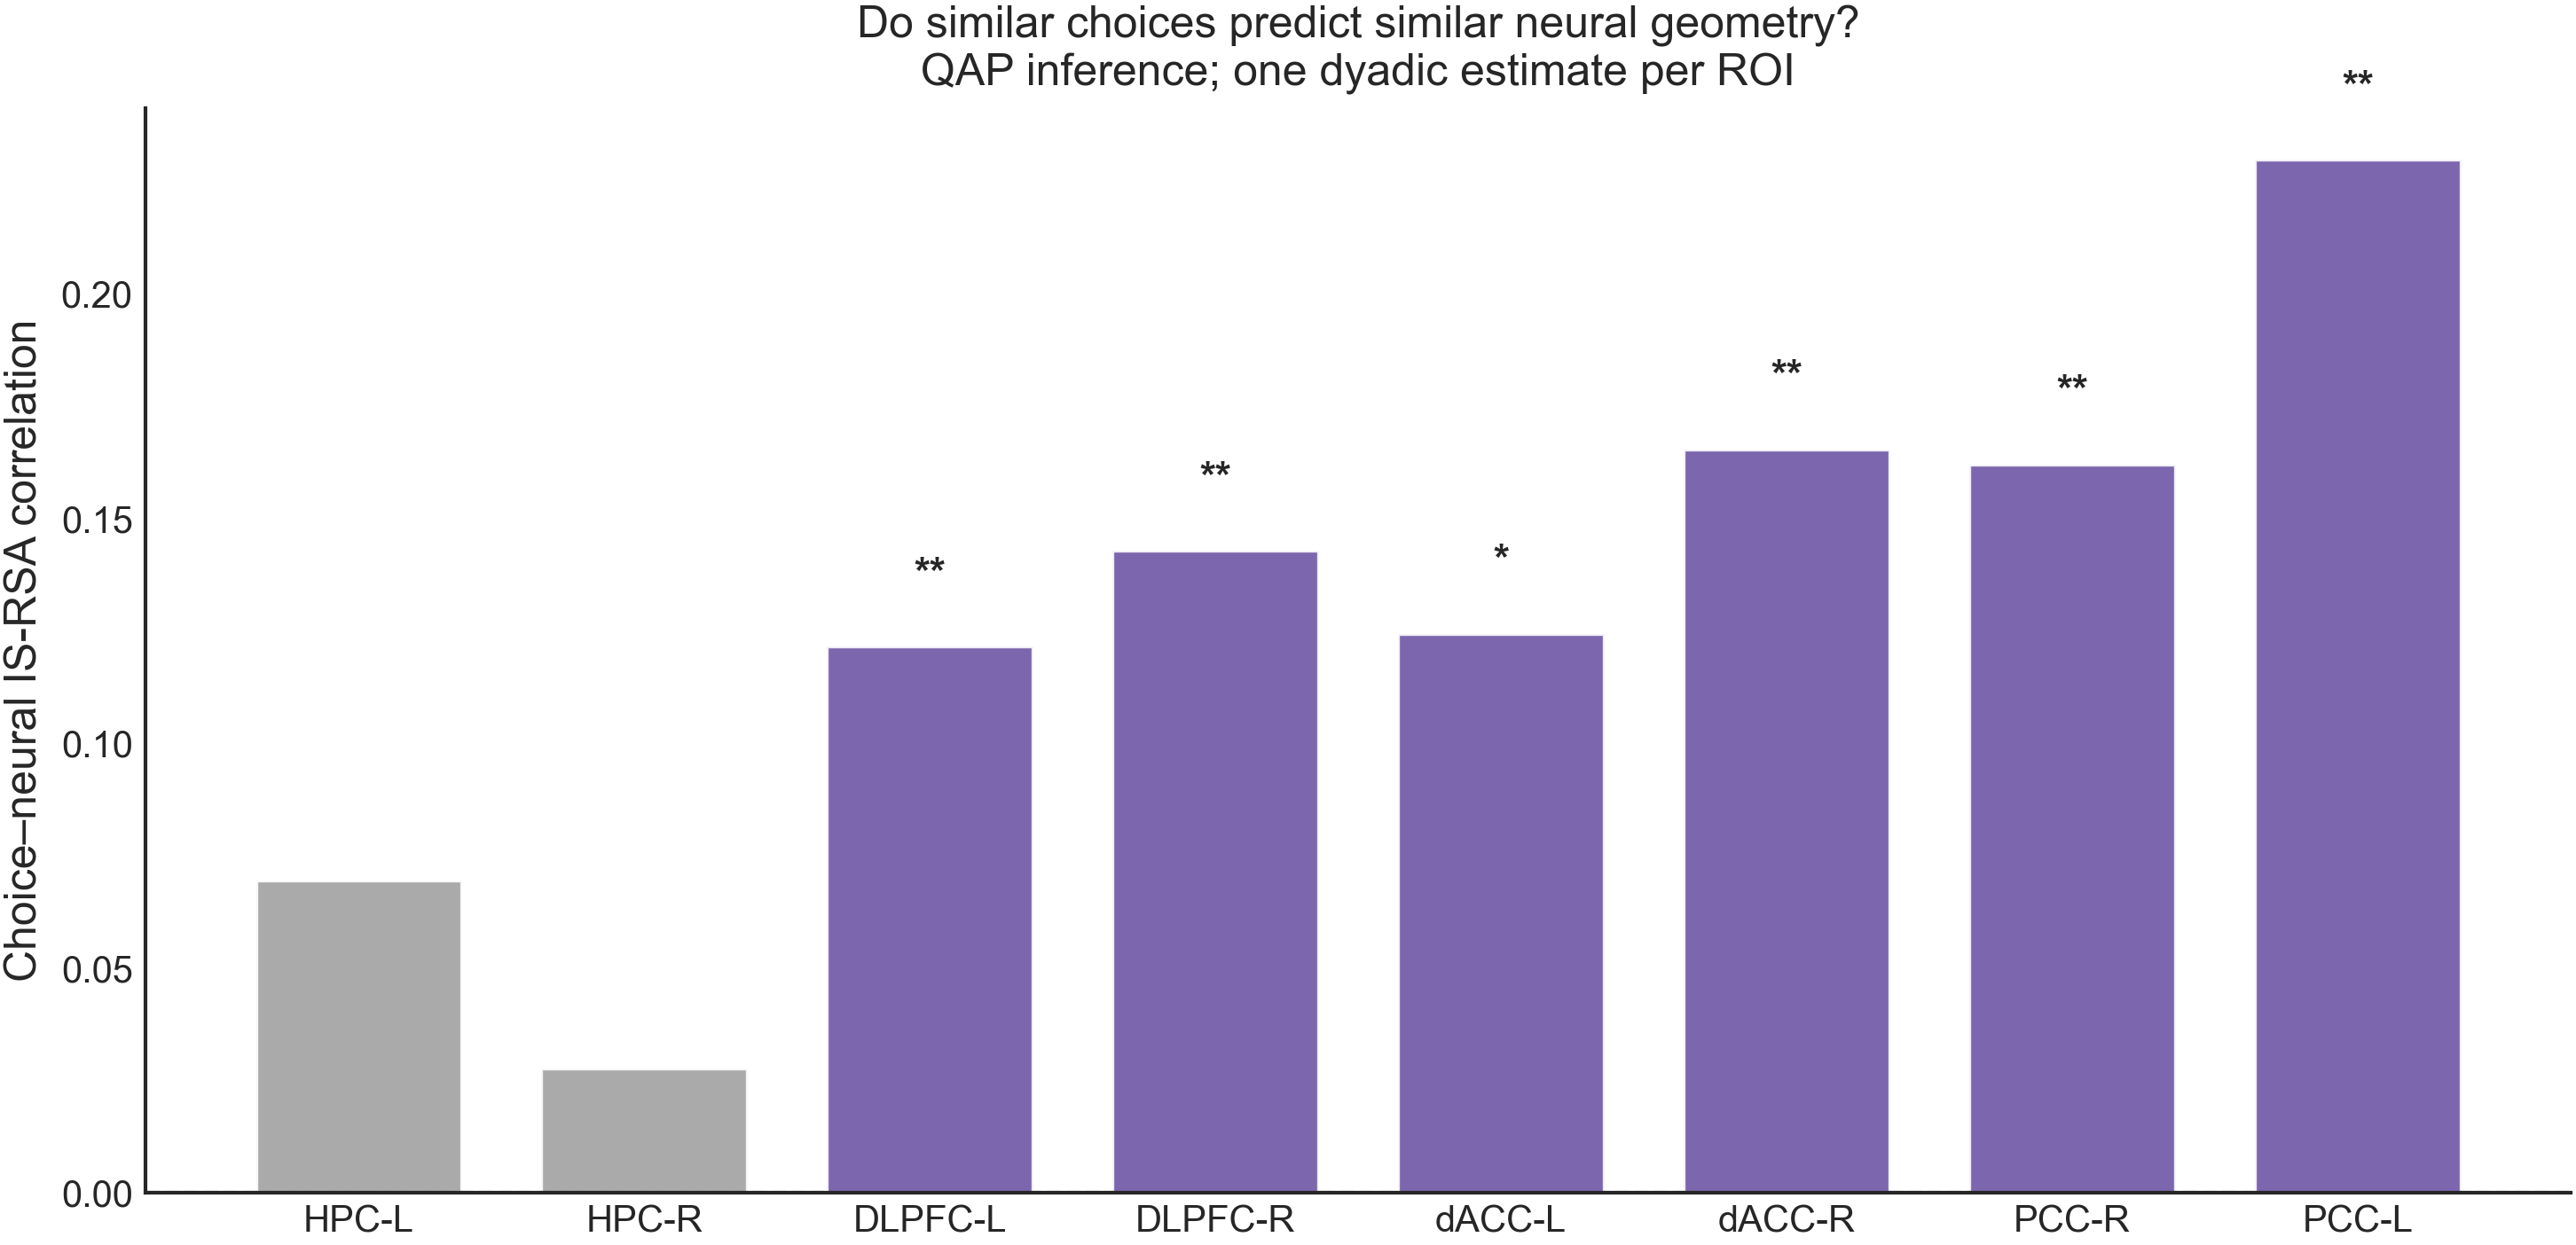

In [5]:
def subject_similarity_matrix(subject_by_pair_matrix):
    similarity = np.corrcoef(subject_by_pair_matrix)
    similarity = fisher_z(similarity)
    np.fill_diagonal(similarity, np.nan)
    return similarity


def qap_correlation(choice_similarity, neural_similarity, permutations):
    n_subjects = choice_similarity.shape[0]
    upper = np.triu_indices(n_subjects, k=1)
    neural_dyads = neural_similarity[upper]
    observed = row_correlation(choice_similarity[upper], neural_dyads)
    null = np.empty(len(permutations), dtype=float)
    for permutation_index, permutation in enumerate(permutations):
        permuted_choice = choice_similarity[np.ix_(permutation, permutation)]
        null[permutation_index] = row_correlation(permuted_choice[upper], neural_dyads)
    p_two_sided = (1 + np.sum(np.abs(null) >= abs(observed))) / (len(null) + 1)
    return observed, p_two_sided, null

rng = np.random.default_rng(RANDOM_SEED)
qap_permutations = np.vstack([
    rng.permutation(len(subject_ids)) for _ in range(N_QAP_PERMUTATIONS)
])

similarity_matrices = {}
choice_results = []
qap_nulls = {}
for roi in rois:
    choice_similarity = subject_similarity_matrix(roi_matrices[roi]['choice_resid'])
    neural_similarity = subject_similarity_matrix(roi_matrices[roi]['neural_resid'])
    observed, p_qap, null = qap_correlation(
        choice_similarity, neural_similarity, qap_permutations
    )
    similarity_matrices[roi] = {
        'choice': choice_similarity,
        'neural': neural_similarity,
    }
    qap_nulls[roi] = null
    choice_results.append({
        'roi': roi,
        'N_participants': len(subject_ids),
        'N_dyads': len(subject_ids) * (len(subject_ids) - 1) // 2,
        'r_choice_neural': observed,
        'p_QAP': p_qap,
        'N_permutations': N_QAP_PERMUTATIONS,
    })

choice_results = pd.DataFrame(choice_results)
choice_results['q_BH'] = benjamini_hochberg(choice_results['p_QAP'])
choice_results['stars'] = choice_results['q_BH'].map(significance_stars)
choice_results['roi'] = pd.Categorical(choice_results['roi'], categories=rois, ordered=True)
choice_results = choice_results.sort_values('roi').reset_index(drop=True)
display(choice_results.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rois))
colors = np.where(choice_results['q_BH'] < 0.05, '#6A51A3', '#9E9E9E')
ax.bar(
    x, choice_results['r_choice_neural'], color=colors,
    width=0.72, alpha=0.88,
)
ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
effect_span = np.ptp(np.r_[0, choice_results['r_choice_neural'].to_numpy()])
star_pad = max(0.05 * effect_span, 0.005)
for index, row in choice_results.iterrows():
    if not row['stars']:
        continue
    positive = row['r_choice_neural'] >= 0
    ax.text(
        index, row['r_choice_neural'] + (star_pad if positive else -star_pad),
        row['stars'], ha='center', va='bottom' if positive else 'top',
        fontsize=11, fontweight='bold',
    )
ax.set(
    xticks=x, xticklabels=rois,
    ylabel='Choice–neural IS-RSA correlation',
    title='Do similar choices predict similar neural geometry?\nQAP inference; one dyadic estimate per ROI',
)
sns.despine()
plt.tight_layout()
plt.show()

## 3. Participant-level choice–neural alignment (descriptive scaffold)

For participant *i*, correlate their choice similarity to every other participant with their neural similarity to every other participant. A high score means that the people whose choices most resemble participant *i* also tend to be the people whose neural geometry most resembles participant *i*.

Bars summarize these participant scores by diagnosis (mean ± SE), with participant strip points overlaid. A two-sided participant-label permutation test compares the CD and HC means while leaving the mutually dependent alignment scores fixed; this is a simple node-label test of whether diagnosis labels are exchangeable over the observed network-derived scores. BH-FDR correction is applied across the eight ROIs, and brackets/asterisks mark adjusted significance (* q < .05, ** q < .01, *** q < .001). This is still an observational group association—not a causal diagnosis effect—and reliability, motion, and other group differences can create apparent individual differences. A fuller dyadic moderator analysis remains a useful next step.

,roi,group,mean,sd,N,se
0,HPC-L,CD,0.040,0.120,31,0.022
1,HPC-L,HC,0.053,0.108,36,0.018
2,HPC-R,CD,-0.007,0.124,31,0.022
3,HPC-R,HC,0.031,0.118,36,0.020
4,DLPFC-L,CD,0.071,0.122,31,0.022
5,DLPFC-L,HC,0.096,0.145,36,0.024
6,DLPFC-R,CD,0.121,0.167,31,0.030
7,DLPFC-R,HC,0.092,0.113,36,0.019
8,dACC-L,CD,0.093,0.118,31,0.021
9,dACC-L,HC,0.094,0.143,36,0.024


,roi,difference_CD_minus_HC,p_label_permutation,q_BH,stars
0,HPC-L,-0.0136,0.6207,0.7975,
1,HPC-R,-0.0381,0.1943,0.7074,
2,DLPFC-L,-0.0251,0.4422,0.7074,
3,DLPFC-R,0.0291,0.4048,0.7074,
4,dACC-L,-0.0015,0.9619,0.9619,
5,dACC-R,-0.0139,0.6978,0.7975,
6,PCC-R,-0.0261,0.4058,0.7074,
7,PCC-L,-0.0525,0.2005,0.7074,


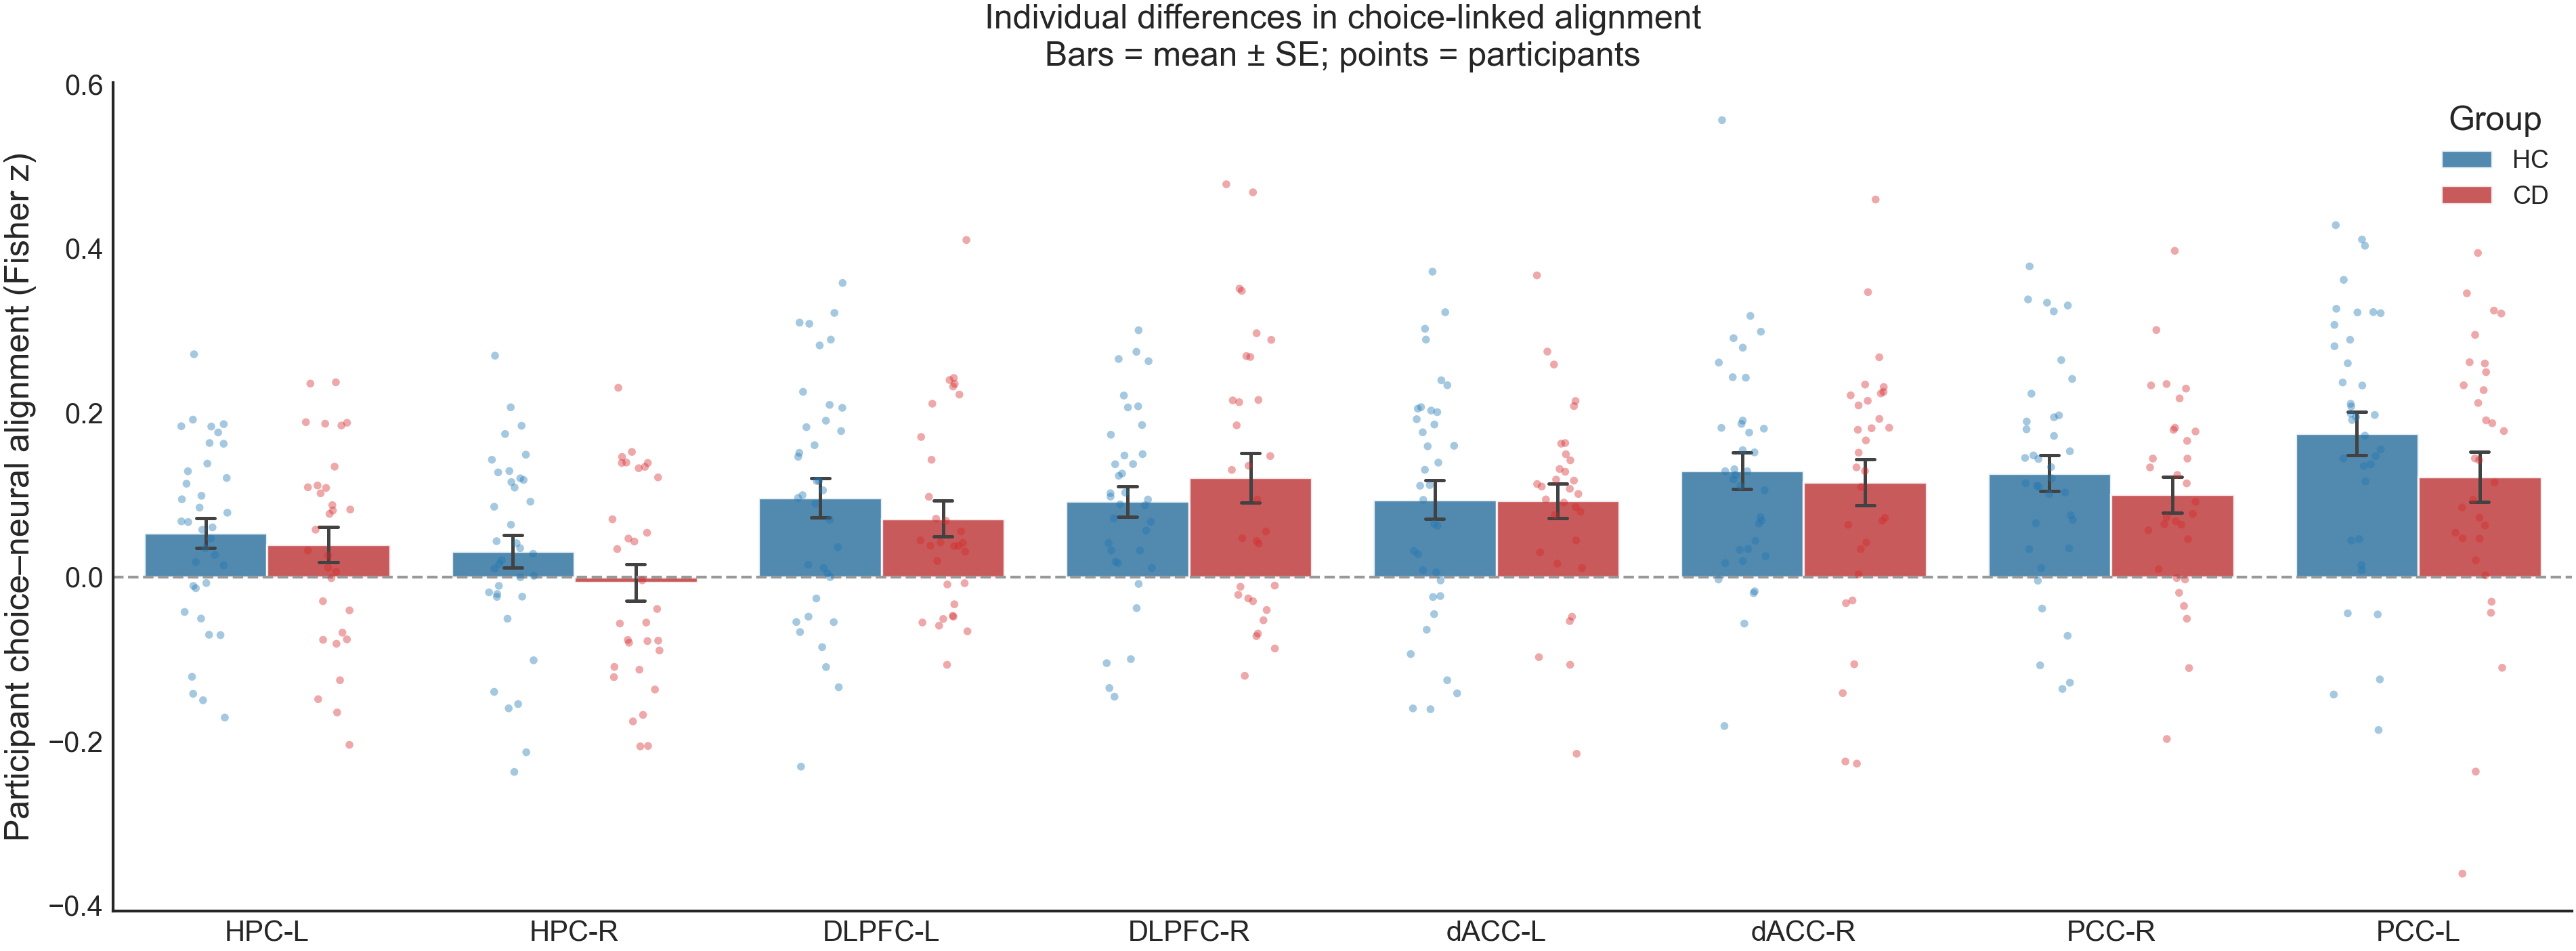

In [6]:
participant_alignment_rows = []
for roi in rois:
    choice_similarity = similarity_matrices[roi]['choice']
    neural_similarity = similarity_matrices[roi]['neural']
    for subject_index, subject_id in enumerate(subject_ids):
        partners = np.arange(len(subject_ids)) != subject_index
        alignment_r = row_correlation(
            choice_similarity[subject_index, partners],
            neural_similarity[subject_index, partners],
        )
        participant_alignment_rows.append({
            'sub_id': subject_id,
            'roi': roi,
            'alignment_r': alignment_r,
            'alignment_z': fisher_z(alignment_r),
        })

participant_alignment = pd.DataFrame(participant_alignment_rows).merge(
    participant_metadata, on='sub_id', how='left'
)
participant_alignment['roi'] = pd.Categorical(
    participant_alignment['roi'], categories=rois, ordered=True
)
alignment_summary = (
    participant_alignment.groupby(['roi', 'group'], observed=True)['alignment_z']
    .agg(mean='mean', sd='std', N='count')
    .reset_index()
)
alignment_summary['se'] = alignment_summary['sd'] / np.sqrt(alignment_summary['N'])

alignment_rng = np.random.default_rng(RANDOM_SEED + 2)
alignment_test_rows = []
for roi, frame in participant_alignment.groupby('roi', observed=True):
    observed, p_value = label_permutation_group_test(
        frame['alignment_z'], frame['group'],
        N_SUBJECT_PERMUTATIONS, alignment_rng,
    )
    alignment_test_rows.append({
        'roi': roi, 'difference_CD_minus_HC': observed,
        'p_label_permutation': p_value,
    })
alignment_tests = pd.DataFrame(alignment_test_rows)
alignment_tests['q_BH'] = benjamini_hochberg(alignment_tests['p_label_permutation'])
alignment_tests['stars'] = alignment_tests['q_BH'].map(significance_stars)
alignment_tests['roi'] = pd.Categorical(
    alignment_tests['roi'], categories=rois, ordered=True
)
alignment_tests = alignment_tests.sort_values('roi').reset_index(drop=True)
display(alignment_summary.round(3))
display(alignment_tests.round(4))

group_order = ['HC', 'CD']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=participant_alignment, x='roi', y='alignment_z', hue='group',
    order=rois, hue_order=group_order, palette=GROUP_PALETTE,
    errorbar='se', capsize=0.12, err_kws={'linewidth': 1.2},
    alpha=0.85, ax=ax,
)
sns.stripplot(
    data=participant_alignment, x='roi', y='alignment_z', hue='group',
    order=rois, hue_order=group_order, palette=GROUP_PALETTE,
    dodge=True, jitter=0.16, size=2.8, alpha=0.40,
    linewidth=0, legend=False, ax=ax,
)

y_span = np.ptp(participant_alignment['alignment_z'].dropna())
bracket_pad = max(0.025 * y_span, 0.005)
bracket_height = max(0.015 * y_span, 0.003)
bracket_tops = []
for roi_index, roi in enumerate(rois):
    test = alignment_tests.query('roi == @roi').iloc[0]
    if not test['stars']:
        continue
    roi_values = participant_alignment.query('roi == @roi')['alignment_z']
    y_bracket = roi_values.max() + bracket_pad
    add_significance_bracket(
        ax, roi_index - 0.2, roi_index + 0.2,
        y_bracket, test['stars'], bracket_height,
    )
    bracket_tops.append(y_bracket + bracket_height + bracket_pad)

ax.axhline(0, color='0.6', linestyle='--', linewidth=1)
if bracket_tops:
    ax.set_ylim(top=max(max(bracket_tops), ax.get_ylim()[1]))
ax.set(
    xlabel='', ylabel='Participant choice–neural alignment (Fisher z)',
    title='Individual differences in choice-linked alignment\nBars = mean ± SE; points = participants',
)
ax.legend(frameon=False, title='Group')
sns.despine()
plt.tight_layout()
plt.show()

## 4. Matched chosen-versus-unchosen specificity

The chosen text is usually one of two fixed option texts, so chosen-text geometry can reflect the presented stimulus set rather than selection-specific representation. This analysis puts the chosen and simultaneously presented unchosen option into the same participant-level regression RSA. It also controls option-set semantics, task structure, scene, selected response, reaction time, movement direction, and word counts.

The primary estimand is the participant-level standardized coefficient contrast **chosen − unchosen**. A positive contrast means neural geometry tracks the selected option more strongly than its matched alternative. Unanswered trials are excluded for that participant; inference is a two-sided participant sign-flip test with BH-FDR across the eight ROI contrasts. Because relationship state and history are downstream of earlier choices, they are not included in this primary model; adding them would estimate a narrower direct-current-choice effect.

beta_chosen         beta_unchosen         choice_specificity          \
               mean     std          mean     std               mean     std   
roi                                                                            
DLPFC-L      0.0051  0.0766        0.0027  0.0710             0.0024  0.0892   
DLPFC-R      0.0007  0.0795        0.0004  0.0742             0.0004  0.0786   
HPC-L       -0.0117  0.0743       -0.0047  0.0749            -0.0071  0.0661   
HPC-R       -0.0155  0.0632        0.0038  0.0724            -0.0193  0.0729   
PCC-L        0.0060  0.0928        0.0113  0.0949            -0.0053  0.0819   
PCC-R       -0.0137  0.0829        0.0108  0.0740            -0.0245  0.0721   
dACC-L      -0.0215  0.1206       -0.0076  0.1099            -0.0138  0.0965   
dACC-R      -0.0358  0.1115       -0.0122  0.1124            -0.0236  0.0965   

        n_valid_trials         n_trial_pairs           condition_number  \
                  mean     std          mean       std             mean   
roi                                                                       
DLPFC-L        58.2687  2.3969     1671.3134  132.7761           9.0725   
DLPFC-R        58.2687  2.3969     1671.3134  132.7761           9.0725   
HPC-L          58.2687  2.3969     1671.3134  132.7761           9.0725   
HPC-R          58.2687  2.3969     1671.3134  132.7761           9.0725   
PCC-L          58.2687  2.3969     1671.3134  132.7761           9.0725   
PCC-R          58.2687  2.3969     1671.3134  132.7761           9.0725   
dACC-L         58.2687  2.3969     1671.3134  132.7761           9.0725   
dACC-R         58.2687  2.3969     1671.3134  132.7761           9.0725   

                 
            std  
roi              
DLPFC-L  0.1184  
DLPFC-R  0.1184  
HPC-L    0.1184  
HPC-R    0.1184  
PCC-L    0.1184  
PCC-R    0.1184  
dACC-L   0.1184  
dACC-R   0.1184

,roi,mean_chosen_minus_unchosen,p_sign_flip,q_BH,stars
0,HPC-L,-0.0071,0.3883,0.6212,
1,HPC-R,-0.0193,0.0317,0.1240,
2,DLPFC-L,0.0024,0.8263,0.9444,
3,DLPFC-R,0.0004,0.9694,0.9694,
4,dACC-L,-0.0138,0.2453,0.4906,
5,dACC-R,-0.0236,0.0465,0.1240,
6,PCC-R,-0.0245,0.0062,0.0496,*
7,PCC-L,-0.0053,0.5977,0.7970,


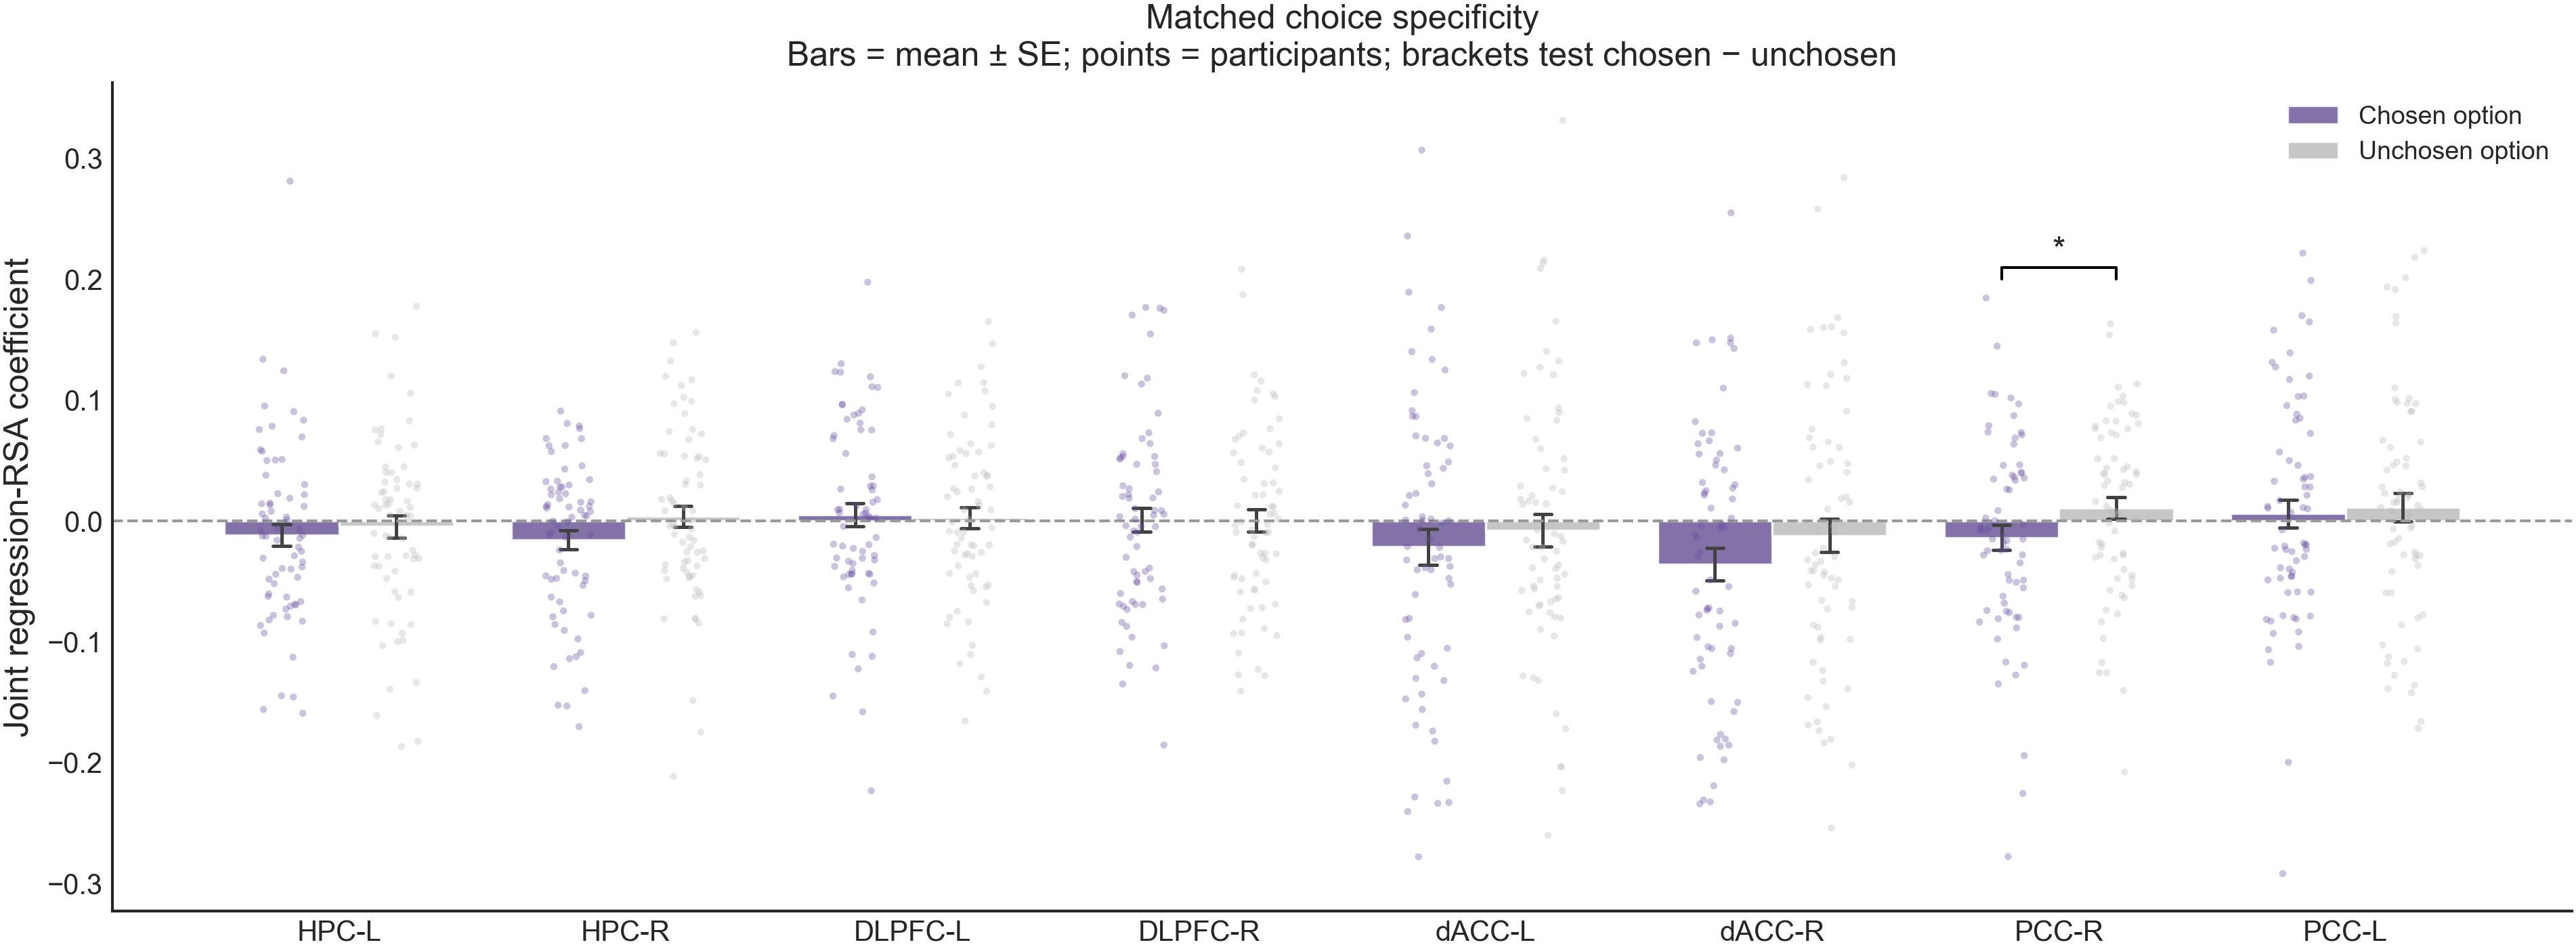

In [7]:
from scipy.spatial.distance import squareform


def normalize_option_text(text):
    return None if pd.isna(text) else str(text).strip()


# Reuse the stored deterministic embeddings: every observed unchosen text is
# chosen by at least one other participant, so no external embedding call is needed.
embedding_samples = {}
for subject in subject_data.values():
    for text, embedding in zip(
        subject['behavior']['chosen_text'], subject['embeddings']['choice']
    ):
        text = normalize_option_text(text)
        if text is not None:
            embedding_samples.setdefault(text, []).append(np.asarray(embedding, float))

option_embedding_lookup = {}
for text, samples in embedding_samples.items():
    samples = np.vstack(samples)
    if not np.allclose(samples, samples[0], atol=1e-10, rtol=1e-10):
        raise ValueError(f'Inconsistent stored embeddings for option text: {text}')
    option_embedding_lookup[text] = samples[0]

all_unchosen_texts = {
    normalize_option_text(text)
    for subject in subject_data.values()
    for text in subject['behavior']['unchosen_text']
    if normalize_option_text(text) is not None
}
if not all_unchosen_texts.issubset(option_embedding_lookup):
    raise ValueError('Some unchosen option texts lack stored embeddings.')


def text_embedding_matrix(texts):
    embedding_size = len(next(iter(option_embedding_lookup.values())))
    matrix = np.full((len(texts), embedding_size), np.nan)
    for trial_index, text in enumerate(texts):
        text = normalize_option_text(text)
        if text in option_embedding_lookup:
            matrix[trial_index] = option_embedding_lookup[text]
    return matrix


def embedding_rdv_allow_missing(embeddings, pair_i, pair_j):
    embeddings = np.asarray(embeddings, dtype=float)
    norms = np.linalg.norm(embeddings, axis=1)
    valid_trials = np.isfinite(embeddings).all(axis=1) & (norms > 0)
    unit = np.full_like(embeddings, np.nan)
    unit[valid_trials] = embeddings[valid_trials] / norms[valid_trials, None]
    valid_pairs = valid_trials[pair_i] & valid_trials[pair_j]
    rdv = np.full(len(pair_i), np.nan)
    rdv[valid_pairs] = 1 - np.sum(
        unit[pair_i[valid_pairs]] * unit[pair_j[valid_pairs]], axis=1
    )
    return rdv, valid_trials


def pairwise_numeric_distance(values, pair_i, pair_j):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return np.abs(values[pair_i] - values[pair_j])
    return np.linalg.norm(values[pair_i] - values[pair_j], axis=1)


def pairwise_mismatch(values, pair_i, pair_j):
    values = np.asarray(values)
    return (values[pair_i] != values[pair_j]).astype(float)


def scalar_sign_flip_test(values, n_permutations, rng):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    observed = values.mean()
    signs = rng.choice([-1.0, 1.0], size=(n_permutations, len(values)))
    null = (signs * values).mean(axis=1)
    p_value = (1 + np.sum(np.abs(null) >= abs(observed))) / (n_permutations + 1)
    return observed, p_value


def fit_matched_choice_rsa(subject, roi, pair_i, pair_j):
    behavior = subject['behavior'].reset_index(drop=True)
    chosen_embeddings = np.asarray(subject['embeddings']['choice'], dtype=float)
    unchosen_embeddings = text_embedding_matrix(behavior['unchosen_text'])
    option1_embeddings = text_embedding_matrix(behavior['opt1_text'])
    option2_embeddings = text_embedding_matrix(behavior['opt2_text'])
    option_set_embeddings = (option1_embeddings + option2_embeddings) / 2

    chosen, chosen_valid = embedding_rdv_allow_missing(
        chosen_embeddings, pair_i, pair_j
    )
    unchosen, unchosen_valid = embedding_rdv_allow_missing(
        unchosen_embeddings, pair_i, pair_j
    )
    option_set, option_valid = embedding_rdv_allow_missing(
        option_set_embeddings, pair_i, pair_j
    )
    responded = behavior['responded'].fillna(False).to_numpy(bool)
    valid_trials = responded & chosen_valid & unchosen_valid & option_valid
    valid_pairs = valid_trials[pair_i] & valid_trials[pair_j]

    controls = task_control_rdvs(behavior, pair_i, pair_j).copy()
    controls['different_scene'] = pairwise_mismatch(
        behavior['scene_num'], pair_i, pair_j
    )
    controls['different_selected_option'] = pairwise_mismatch(
        behavior['selected_option'].fillna(-1), pair_i, pair_j
    )
    controls['reaction_time_distance'] = pairwise_numeric_distance(
        behavior['reaction_time'].fillna(behavior['reaction_time'].median()),
        pair_i, pair_j,
    )
    movement = behavior[['affil_decision', 'power_decision']].fillna(0).to_numpy(float)
    controls['movement_distance'] = pairwise_numeric_distance(
        movement, pair_i, pair_j
    )
    controls['chosen_word_count_distance'] = pairwise_numeric_distance(
        behavior['chosen_words'].fillna(0), pair_i, pair_j
    )
    controls['unchosen_word_count_distance'] = pairwise_numeric_distance(
        behavior['unchosen_words'].fillna(0), pair_i, pair_j
    )
    controls['option_set_semantics'] = option_set
    controls['chosen_semantics'] = chosen
    controls['unchosen_semantics'] = unchosen

    neural = neural_rdv(subject['roi_betas'][roi])
    model_mask = (
        valid_pairs
        & np.isfinite(neural)
        & np.isfinite(controls.to_numpy(float)).all(axis=1)
    )
    y = safe_zscore(neural[model_mask])
    predictor_names, predictor_columns = [], []
    for column in controls:
        values = controls[column].to_numpy(float)[model_mask]
        if np.std(values) > 0:
            predictor_names.append(column)
            predictor_columns.append(safe_zscore(values))
    X = np.column_stack([np.ones(model_mask.sum()), *predictor_columns])
    coefficients = np.linalg.lstsq(X, y, rcond=None)[0][1:]
    coefficient_map = dict(zip(predictor_names, coefficients))
    return {
        'beta_chosen': coefficient_map['chosen_semantics'],
        'beta_unchosen': coefficient_map['unchosen_semantics'],
        'choice_specificity': (
            coefficient_map['chosen_semantics']
            - coefficient_map['unchosen_semantics']
        ),
        'n_valid_trials': int(valid_trials.sum()),
        'n_trial_pairs': int(model_mask.sum()),
        'condition_number': float(np.linalg.cond(X)),
    }


pair_i, pair_j = trial_pair_indices
matched_rows = []
for subject_id in subject_ids:
    for roi in rois:
        result = fit_matched_choice_rsa(subject_data[subject_id], roi, pair_i, pair_j)
        matched_rows.append({'sub_id': subject_id, 'roi': roi, **result})
matched_choice = pd.DataFrame(matched_rows).merge(
    participant_metadata, on='sub_id', how='left'
)

matched_long = matched_choice.melt(
    id_vars=['sub_id', 'roi', 'group'],
    value_vars=['beta_chosen', 'beta_unchosen'],
    var_name='component', value_name='standardized_beta',
)
matched_long['component'] = matched_long['component'].map({
    'beta_chosen': 'Chosen option', 'beta_unchosen': 'Unchosen option',
})
matched_long['roi'] = pd.Categorical(matched_long['roi'], categories=rois, ordered=True)

matched_rng = np.random.default_rng(RANDOM_SEED + 3)
matched_test_rows = []
for roi, frame in matched_choice.groupby('roi', observed=True):
    observed, p_value = scalar_sign_flip_test(
        frame['choice_specificity'], N_SUBJECT_PERMUTATIONS, matched_rng
    )
    matched_test_rows.append({
        'roi': roi, 'mean_chosen_minus_unchosen': observed,
        'p_sign_flip': p_value,
    })
matched_tests = pd.DataFrame(matched_test_rows)
matched_tests['q_BH'] = benjamini_hochberg(matched_tests['p_sign_flip'])
matched_tests['stars'] = matched_tests['q_BH'].map(significance_stars)
matched_tests['roi'] = pd.Categorical(
    matched_tests['roi'], categories=rois, ordered=True
)
matched_tests = matched_tests.sort_values('roi').reset_index(drop=True)

display(
    matched_choice.groupby('roi', observed=True)[
        ['beta_chosen', 'beta_unchosen', 'choice_specificity',
         'n_valid_trials', 'n_trial_pairs', 'condition_number']
    ].agg(['mean', 'std']).round(4)
)
display(matched_tests.round(4))

matched_palette = {'Chosen option': '#6A51A3', 'Unchosen option': '#BDBDBD'}
component_order = ['Chosen option', 'Unchosen option']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=matched_long, x='roi', y='standardized_beta', hue='component',
    order=rois, hue_order=component_order, palette=matched_palette,
    errorbar='se', capsize=0.12, err_kws={'linewidth': 1.2},
    alpha=0.86, ax=ax,
)
sns.stripplot(
    data=matched_long, x='roi', y='standardized_beta', hue='component',
    order=rois, hue_order=component_order, palette=matched_palette,
    dodge=True, jitter=0.16, size=2.5, alpha=0.35,
    linewidth=0, legend=False, ax=ax,
)
matched_span = np.ptp(matched_long['standardized_beta'])
bracket_pad = max(0.025 * matched_span, 0.004)
bracket_height = max(0.015 * matched_span, 0.003)
bracket_tops = []
for roi_index, roi in enumerate(rois):
    test = matched_tests.query('roi == @roi').iloc[0]
    if not test['stars']:
        continue
    y = matched_long.query('roi == @roi')['standardized_beta'].max() + bracket_pad
    add_significance_bracket(
        ax, roi_index - 0.2, roi_index + 0.2, y,
        test['stars'], bracket_height,
    )
    bracket_tops.append(y + bracket_height + bracket_pad)
ax.axhline(0, color='0.6', linestyle='--', linewidth=1)
if bracket_tops:
    ax.set_ylim(top=max(max(bracket_tops), ax.get_ylim()[1]))
ax.set(
    xlabel='', ylabel='Joint regression-RSA coefficient',
    title='Matched choice specificity\nBars = mean ± SE; points = participants; brackets test chosen − unchosen',
)
ax.legend(frameon=False, title='')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Remove participant typicality and group clustering

The original dyadic association can be inflated if some participants are generally similar to everyone in both choice and neural space. Double-centering each subject-similarity matrix removes its additive row and column tendencies before QAP. The same centered analysis is then repeated separately in HC and CD participants, so an across-group separation cannot produce the within-group effects.

These are deliberately stringent stress tests. BH-FDR is applied jointly across the 24 ROI × sample tests. A surviving effect means precise dyadic matching remains after removing global participant typicality; it still does not establish a causal choice effect.

,roi,sample,N_participants,r_choice_neural,p_QAP,q_BH,stars
0,HPC-L,All centered,67,0.0451,0.0350,0.1139,
1,HPC-L,CD centered,31,0.1039,0.0260,0.1139,
2,HPC-L,HC centered,36,-0.0078,0.8482,0.8791,
3,HPC-R,All centered,67,0.0246,0.2567,0.3681,
4,HPC-R,CD centered,31,-0.0431,0.3616,0.4568,
5,HPC-R,HC centered,36,0.0532,0.1948,0.3340,
6,DLPFC-L,All centered,67,0.0459,0.0370,0.1139,
7,DLPFC-L,CD centered,31,0.0315,0.5445,0.6103,
8,DLPFC-L,HC centered,36,0.0520,0.2118,0.3389,
9,DLPFC-R,All centered,67,0.0482,0.0240,0.1139,


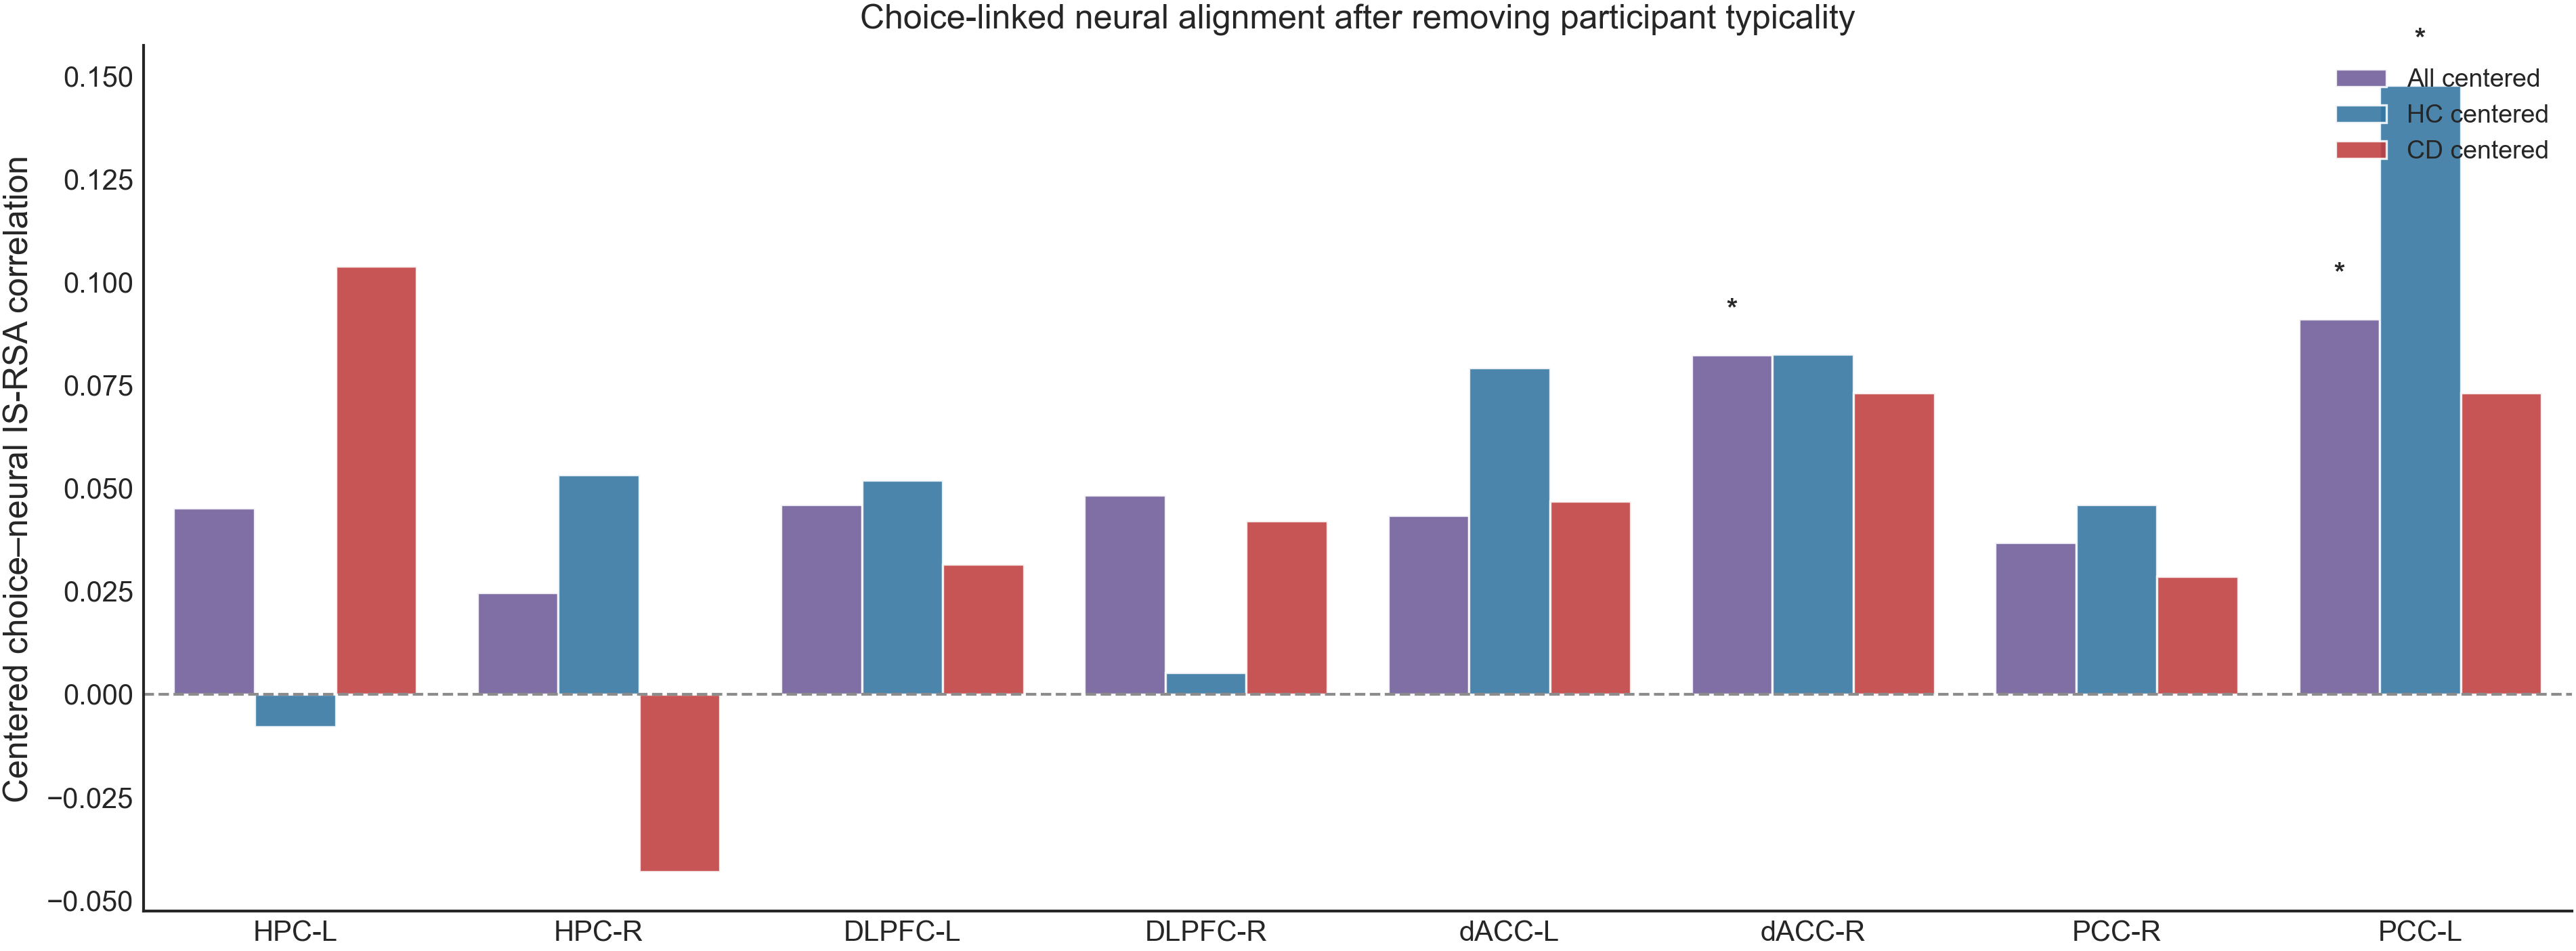

In [8]:
def double_center_hollow(matrix):
    matrix = np.asarray(matrix, dtype=float).copy()
    np.fill_diagonal(matrix, np.nan)
    row_means = np.nanmean(matrix, axis=1)
    grand_mean = np.nanmean(matrix)
    centered = matrix - row_means[:, None] - row_means[None, :] + grand_mean
    np.fill_diagonal(centered, np.nan)
    return centered


subject_groups = np.array([metadata_by_id.loc[subject_id, 'group'] for subject_id in subject_ids])
stress_samples = {
    'All centered': np.arange(len(subject_ids)),
    'HC centered': np.flatnonzero(subject_groups == 'HC'),
    'CD centered': np.flatnonzero(subject_groups == 'CD'),
}
stress_rng = np.random.default_rng(RANDOM_SEED + 4)
stress_permutations = {
    label: np.vstack([
        stress_rng.permutation(len(indices)) for _ in range(N_QAP_PERMUTATIONS)
    ])
    for label, indices in stress_samples.items()
}

stress_rows = []
stress_nulls = {}
for roi in rois:
    for sample_label, indices in stress_samples.items():
        choice = similarity_matrices[roi]['choice'][np.ix_(indices, indices)]
        neural = similarity_matrices[roi]['neural'][np.ix_(indices, indices)]
        choice = double_center_hollow(choice)
        neural = double_center_hollow(neural)
        observed, p_value, null = qap_correlation(
            choice, neural, stress_permutations[sample_label]
        )
        stress_rows.append({
            'roi': roi, 'sample': sample_label,
            'N_participants': len(indices),
            'r_choice_neural': observed, 'p_QAP': p_value,
        })
        stress_nulls[(roi, sample_label)] = null

stress_results = pd.DataFrame(stress_rows)
stress_results['q_BH'] = benjamini_hochberg(stress_results['p_QAP'])
stress_results['stars'] = stress_results['q_BH'].map(significance_stars)
stress_results['roi'] = pd.Categorical(
    stress_results['roi'], categories=rois, ordered=True
)
stress_results = stress_results.sort_values(['roi', 'sample']).reset_index(drop=True)
display(stress_results.round(4))

sample_order = list(stress_samples)
stress_palette = {
    'All centered': '#6A51A3',
    'HC centered': GROUP_PALETTE['HC'],
    'CD centered': GROUP_PALETTE['CD'],
}
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=stress_results, x='roi', y='r_choice_neural', hue='sample',
    order=rois, hue_order=sample_order, palette=stress_palette,
    errorbar=None, alpha=0.88, ax=ax,
)
effect_span = np.ptp(np.r_[0, stress_results['r_choice_neural'].to_numpy()])
star_pad = max(0.04 * effect_span, 0.004)
sample_offsets = np.linspace(-0.8 / 3, 0.8 / 3, len(sample_order))
for roi_index, roi in enumerate(rois):
    for sample_index, sample_label in enumerate(sample_order):
        row = stress_results.query(
            'roi == @roi and sample == @sample_label'
        ).iloc[0]
        if not row['stars']:
            continue
        positive = row['r_choice_neural'] >= 0
        ax.text(
            roi_index + sample_offsets[sample_index],
            row['r_choice_neural'] + (star_pad if positive else -star_pad),
            row['stars'], ha='center', va='bottom' if positive else 'top',
            fontsize=10, fontweight='bold',
        )
ax.axhline(0, color='0.55', linestyle='--', linewidth=1)
ax.set(
    xlabel='', ylabel='Centered choice–neural IS-RSA correlation',
    title='Choice-linked neural alignment after removing participant typicality',
)
ax.legend(frameon=False, title='')
sns.despine()
plt.tight_layout()
plt.show()

### 5b. Cross-half generalization

To reduce same-trial stimulus and noise explanations, trials are alternated into two halves within each character × decision-dimension stratum. Choice similarity estimated from half A is related to neural similarity from half B, and vice versa; the two correlations are averaged. Subject-similarity matrices are double-centered before QAP. A surviving effect therefore reflects a participant-pair correspondence that generalizes across disjoint task events, although the underlying RDM reliability can still limit power. BH-FDR is applied across the eight ROIs.

Trials in half A    32
Trials in half B    31
Name: Stratified split, dtype: int64

,roi,crosshalf_r,p_QAP,N_participants,N_pairs_half_A,N_pairs_half_B,q_BH,stars
0,HPC-L,0.0145,0.3576,67,496,465,0.5722,
1,HPC-R,-0.0045,0.7812,67,496,465,0.8022,
2,DLPFC-L,0.0257,0.1019,67,496,465,0.2038,
3,DLPFC-R,0.0291,0.0709,67,496,465,0.1891,
4,dACC-L,0.0032,0.8022,67,496,465,0.8022,
5,dACC-R,0.0296,0.0589,67,496,465,0.1891,
6,PCC-R,-0.0049,0.7423,67,496,465,0.8022,
7,PCC-L,0.0310,0.0470,67,496,465,0.1891,


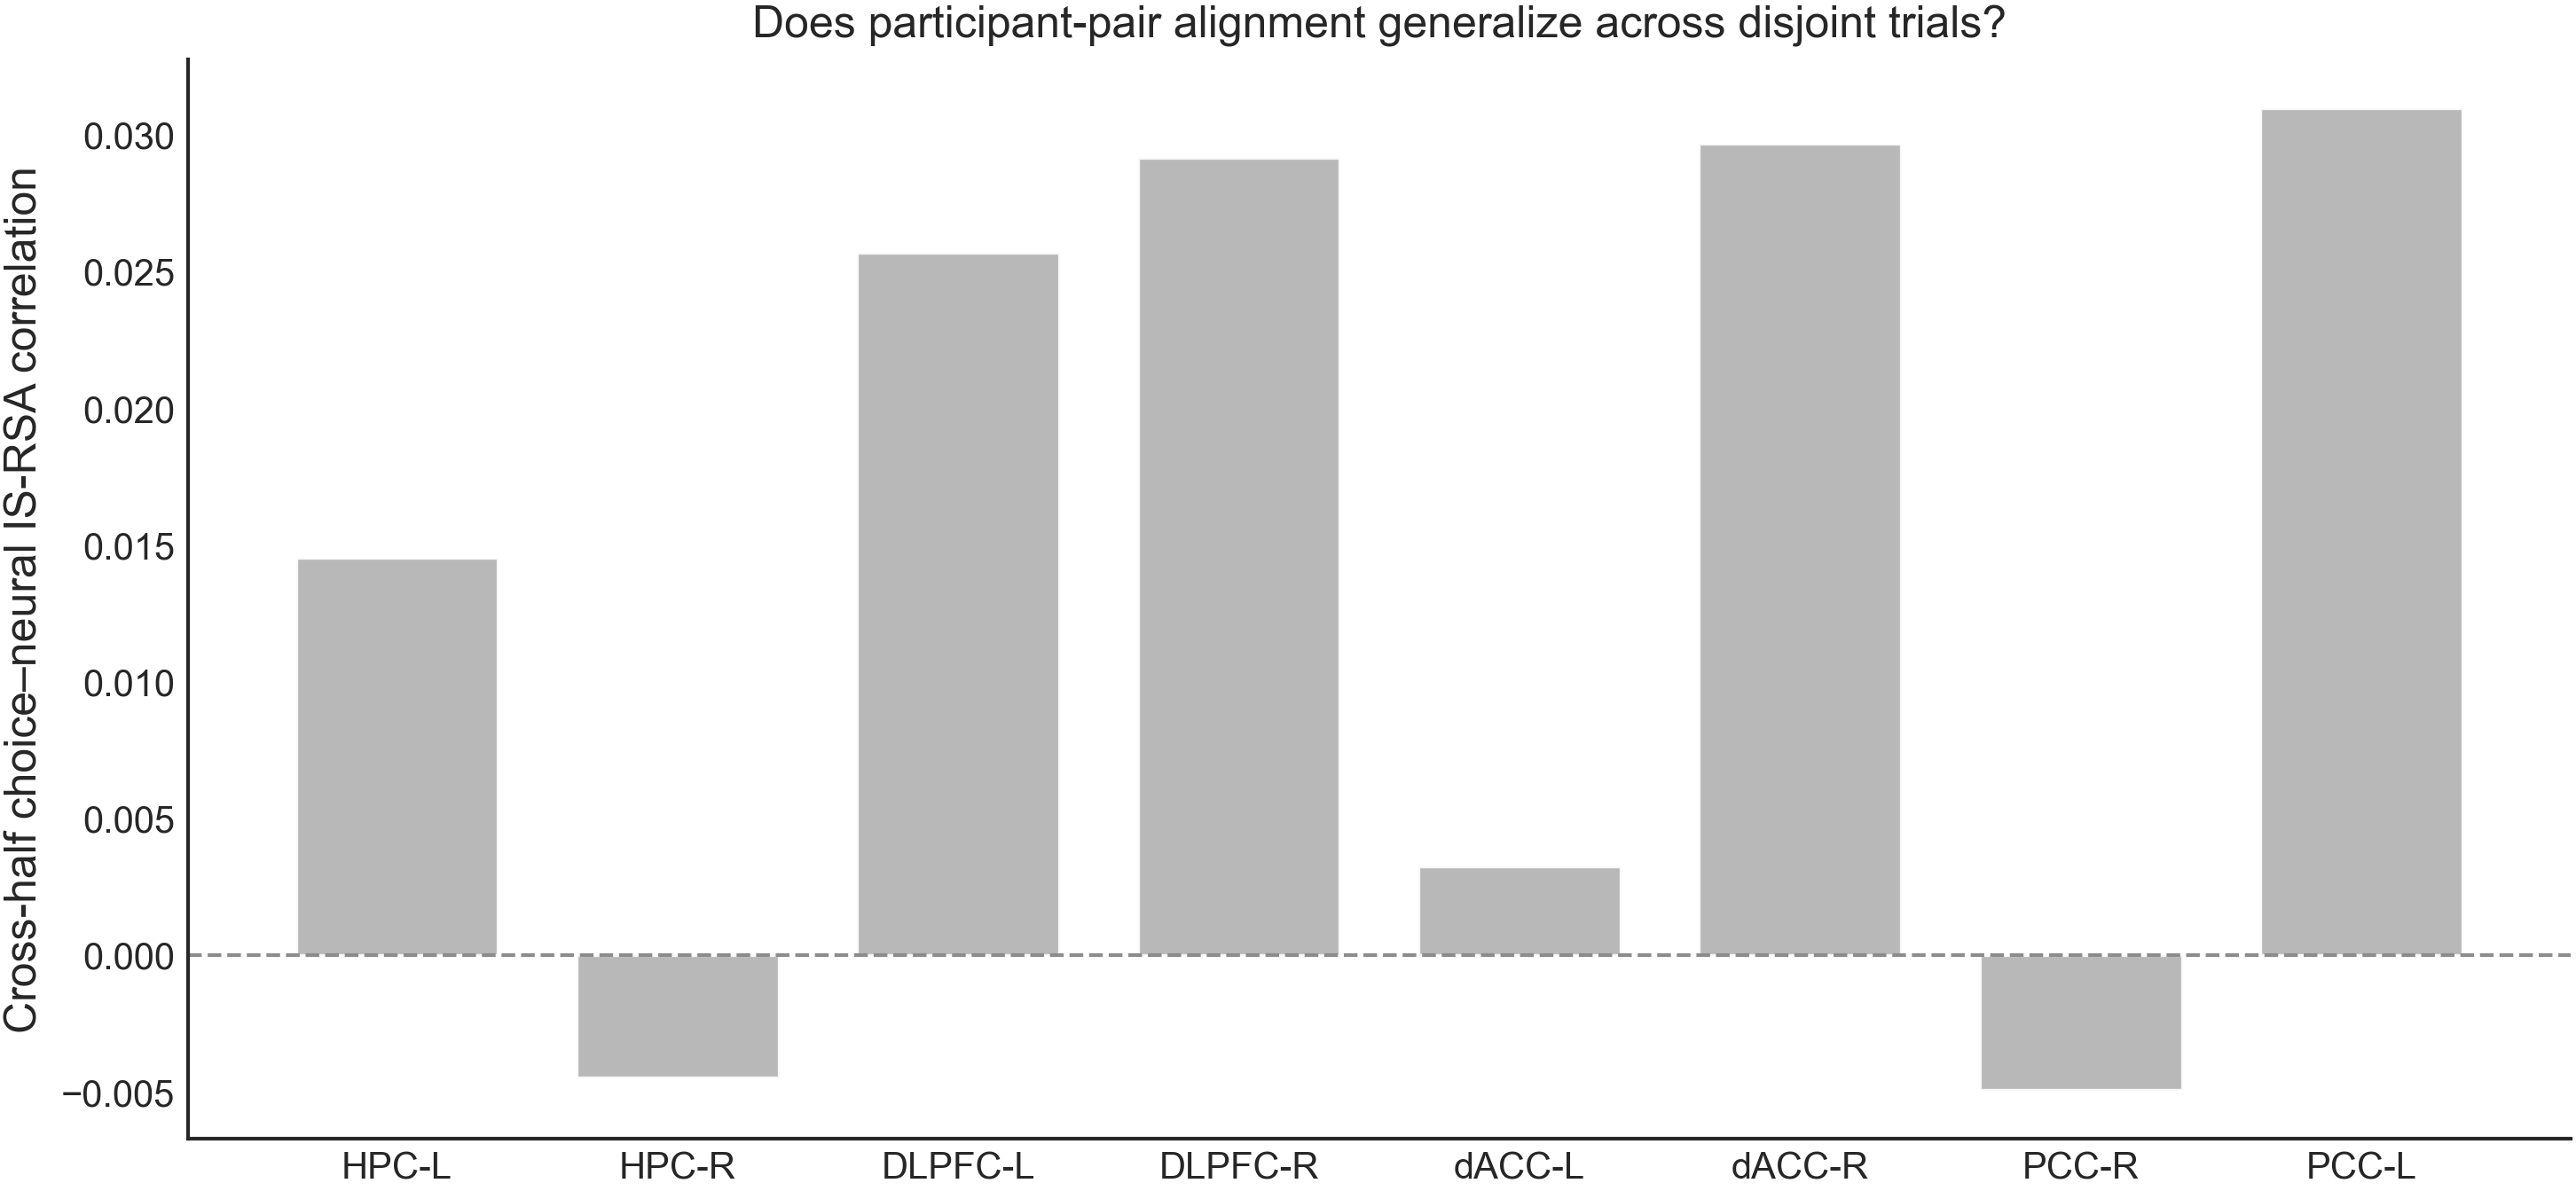

In [9]:
def crosshalf_qap(choice_a, choice_b, neural_a, neural_b, permutations):
    n_subjects = choice_a.shape[0]
    upper = np.triu_indices(n_subjects, k=1)
    observed = np.mean([
        row_correlation(choice_a[upper], neural_b[upper]),
        row_correlation(choice_b[upper], neural_a[upper]),
    ])
    null = np.empty(len(permutations), dtype=float)
    for permutation_index, permutation in enumerate(permutations):
        permuted_a = choice_a[np.ix_(permutation, permutation)]
        permuted_b = choice_b[np.ix_(permutation, permutation)]
        null[permutation_index] = np.mean([
            row_correlation(permuted_a[upper], neural_b[upper]),
            row_correlation(permuted_b[upper], neural_a[upper]),
        ])
    p_value = (1 + np.sum(np.abs(null) >= abs(observed))) / (len(null) + 1)
    return observed, p_value, null


reference_behavior = subject_data[subject_ids[0]]['behavior'].reset_index(drop=True)
trial_half = np.full(len(reference_behavior), -1, dtype=int)
for _, trial_indices in reference_behavior.groupby(
    ['character_role_num', 'dimension'], sort=True
).groups.items():
    ordered = reference_behavior.loc[list(trial_indices)].sort_values('decision_num').index
    trial_half[ordered[::2]] = 0
    trial_half[ordered[1::2]] = 1
if np.any(trial_half < 0):
    raise ValueError('Not all trials were assigned to a cross-validation half.')

crosshalf_rng = np.random.default_rng(RANDOM_SEED + 6)
crosshalf_permutations = np.vstack([
    crosshalf_rng.permutation(len(subject_ids))
    for _ in range(N_QAP_PERMUTATIONS)
])
crosshalf_rows = []
crosshalf_nulls = {}
for roi in rois:
    common_pair_mask = roi_matrices[roi]['mask']
    retained_pair_i = pair_i[common_pair_mask]
    retained_pair_j = pair_j[common_pair_mask]
    half_a_pairs = (
        (trial_half[retained_pair_i] == 0) & (trial_half[retained_pair_j] == 0)
    )
    half_b_pairs = (
        (trial_half[retained_pair_i] == 1) & (trial_half[retained_pair_j] == 1)
    )
    choice_a = double_center_hollow(subject_similarity_matrix(
        roi_matrices[roi]['choice_resid'][:, half_a_pairs]
    ))
    choice_b = double_center_hollow(subject_similarity_matrix(
        roi_matrices[roi]['choice_resid'][:, half_b_pairs]
    ))
    neural_a = double_center_hollow(subject_similarity_matrix(
        roi_matrices[roi]['neural_resid'][:, half_a_pairs]
    ))
    neural_b = double_center_hollow(subject_similarity_matrix(
        roi_matrices[roi]['neural_resid'][:, half_b_pairs]
    ))
    observed, p_value, null = crosshalf_qap(
        choice_a, choice_b, neural_a, neural_b, crosshalf_permutations
    )
    crosshalf_rows.append({
        'roi': roi, 'crosshalf_r': observed, 'p_QAP': p_value,
        'N_participants': len(subject_ids),
        'N_pairs_half_A': int(half_a_pairs.sum()),
        'N_pairs_half_B': int(half_b_pairs.sum()),
    })
    crosshalf_nulls[roi] = null

crosshalf_results = pd.DataFrame(crosshalf_rows)
crosshalf_results['q_BH'] = benjamini_hochberg(crosshalf_results['p_QAP'])
crosshalf_results['stars'] = crosshalf_results['q_BH'].map(significance_stars)
crosshalf_results['roi'] = pd.Categorical(
    crosshalf_results['roi'], categories=rois, ordered=True
)
crosshalf_results = crosshalf_results.sort_values('roi').reset_index(drop=True)
display(pd.Series({
    'Trials in half A': int(np.sum(trial_half == 0)),
    'Trials in half B': int(np.sum(trial_half == 1)),
}, name='Stratified split'))
display(crosshalf_results.round(4))

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(rois))
bar_colors = np.where(crosshalf_results['q_BH'] < 0.05, '#6A51A3', '#AFAFAF')
ax.bar(x, crosshalf_results['crosshalf_r'], color=bar_colors, width=0.72, alpha=0.88)
crosshalf_span = np.ptp(np.r_[0, crosshalf_results['crosshalf_r'].to_numpy()])
star_pad = max(0.05 * crosshalf_span, 0.003)
for index, row in crosshalf_results.iterrows():
    if not row['stars']:
        continue
    positive = row['crosshalf_r'] >= 0
    ax.text(
        index, row['crosshalf_r'] + (star_pad if positive else -star_pad),
        row['stars'], ha='center', va='bottom' if positive else 'top',
        fontweight='bold',
    )
ax.axhline(0, color='0.55', linestyle='--', linewidth=1)
ax.set(
    xticks=x, xticklabels=rois,
    ylabel='Cross-half choice–neural IS-RSA correlation',
    title='Does participant-pair alignment generalize across disjoint trials?',
)
sns.despine()
plt.tight_layout()
plt.show()

## 6. External-person block decomposition

This final section asks which kinds of participant similarity uniquely track neural-geometry similarity after the other measured components are present. Five blocks are entered together: choice geometry, subjective social-map geometry, stable psychosocial traits, quality/engagement, and demographic/design similarity. All matrices are double-centered first, so the model targets precise dyadic matching beyond additive participant typicality.

For each block and ROI, the statistic is its unique incremental in-sample ΔR²: full-model R² minus the R² of a model omitting that block. Conditional Freedman–Lane QAP permutes the reduced-model residual matrix by participant labels before refitting both models. BH-FDR is applied across the eight ROIs separately for each prespecified block. The unique increments do **not** add to total R², because correlated blocks share explanatory variance. This is a statistical decomposition, not a causal or biological partition.

The stable-trait block is intentionally compact (childhood trauma, attachment anxiety/avoidance, and social-network size) rather than using the hundreds of available questionnaire variables. The one participant with entirely missing subjective-map coordinates is excluded from this section only.

,roi,block,unique_delta_R2,full_model_R2,p_QAP,N_participants,q_BH,stars
0,HPC-L,Choice geometry,0.0019,0.0037,0.0470,66,0.0733,
1,HPC-L,Subjective map,0.0000,0.0037,0.7922,66,0.9054,
2,HPC-L,Stable traits,0.0006,0.0037,0.2408,66,0.6074,
3,HPC-L,Quality / engagement,0.0001,0.0037,0.7063,66,0.8641,
4,HPC-L,Demographic / design,0.0009,0.0037,0.7732,66,0.8837,
5,HPC-R,Choice geometry,0.0010,0.0039,0.1449,66,0.1449,
6,HPC-R,Subjective map,0.0005,0.0039,0.3237,66,0.5722,
7,HPC-R,Stable traits,0.0004,0.0039,0.3516,66,0.6074,
8,HPC-R,Quality / engagement,0.0000,0.0039,0.8641,66,0.8641,
9,HPC-R,Demographic / design,0.0020,0.0039,0.3596,66,0.6780,


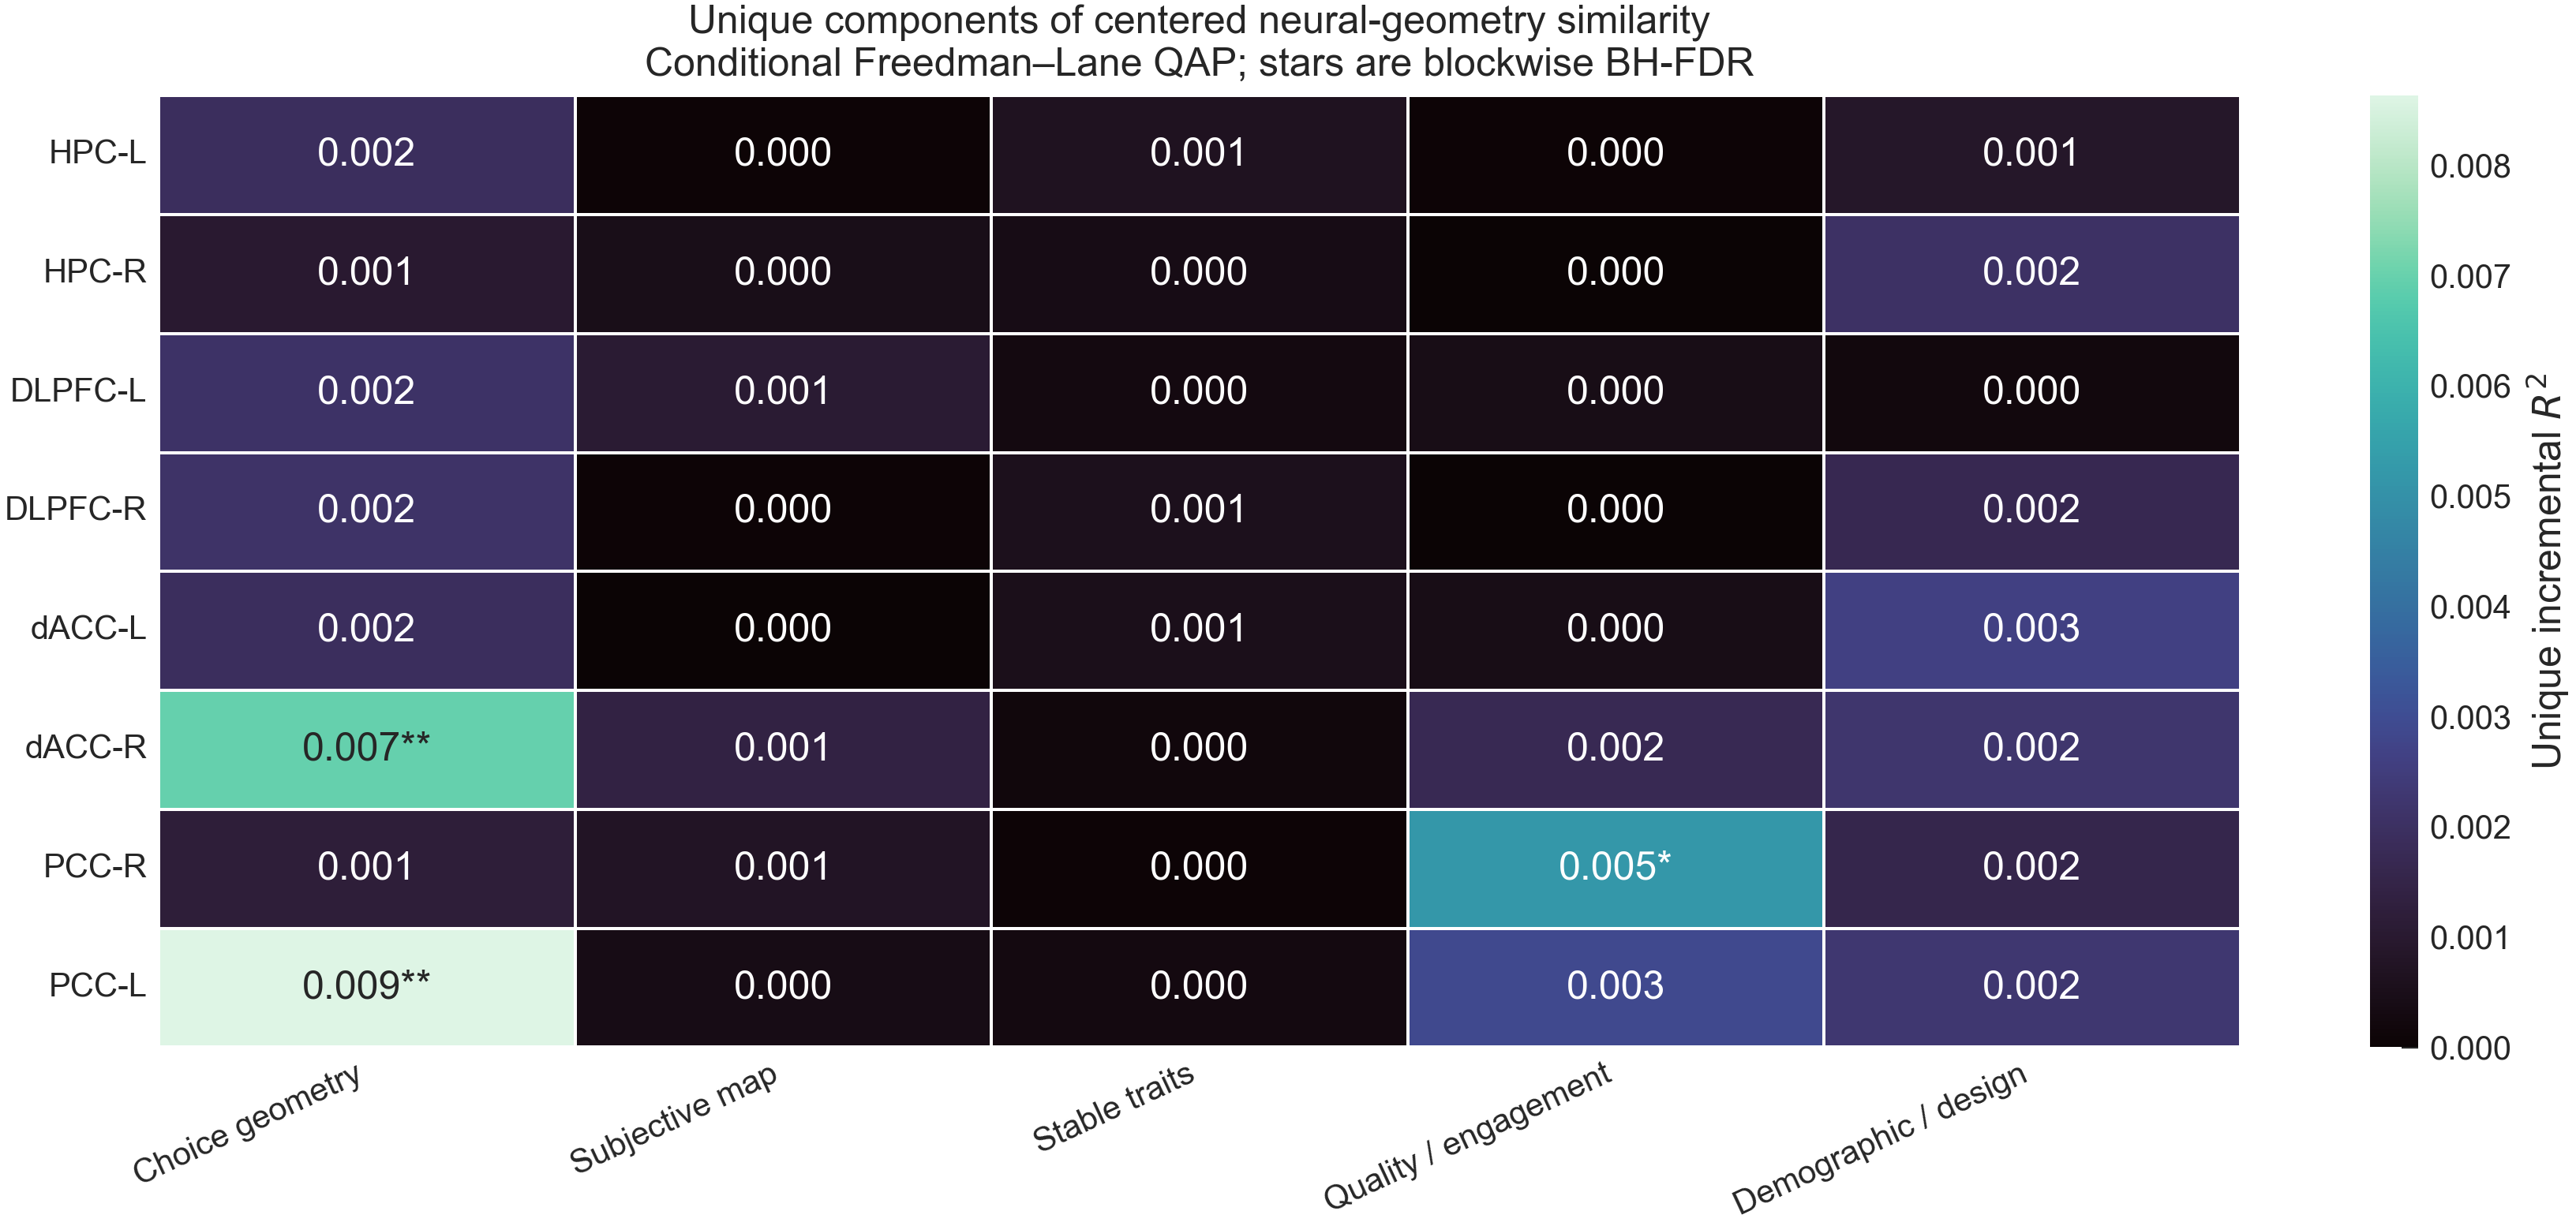

In [10]:
def profile_similarity_matrix(features):
    features = np.asarray(features, dtype=float)
    feature_sd = features.std(axis=0, ddof=0)
    keep = np.isfinite(feature_sd) & (feature_sd > 0)
    z = (features[:, keep] - features[:, keep].mean(axis=0)) / feature_sd[keep]
    similarity = -squareform(pdist(z, metric='euclidean')) / np.sqrt(z.shape[1])
    np.fill_diagonal(similarity, np.nan)
    return similarity


def categorical_match_matrix(values):
    values = np.asarray(values)
    matrix = (values[:, None] == values[None, :]).astype(float)
    np.fill_diagonal(matrix, np.nan)
    return matrix


def continuous_similarity_matrix(values):
    values = safe_zscore(np.asarray(values, dtype=float))
    matrix = -np.abs(values[:, None] - values[None, :])
    np.fill_diagonal(matrix, np.nan)
    return matrix


def orthonormal_basis(design):
    u, singular_values, _ = np.linalg.svd(design, full_matrices=False)
    tolerance = np.finfo(float).eps * max(design.shape) * singular_values[0]
    return u[:, singular_values > tolerance]


def regression_r_squared(y, design):
    basis = orthonormal_basis(design)
    fitted = basis @ (basis.T @ y)
    residual = y - fitted
    tss = np.sum((y - y.mean()) ** 2)
    return 1 - np.sum(residual ** 2) / tss, fitted, residual


def freedman_lane_block_test(outcome, block_matrices, target_block, permutations):
    n_subjects = outcome.shape[0]
    upper = np.triu_indices(n_subjects, k=1)
    y = outcome[upper]
    columns, column_blocks = [], []
    for block, matrices in block_matrices.items():
        for matrix in matrices:
            vector = matrix[upper]
            if np.std(vector) > 0:
                columns.append(safe_zscore(vector))
                column_blocks.append(block)
    X_full = np.column_stack([np.ones(len(y)), *columns])
    keep_reduced = [True] + [block != target_block for block in column_blocks]
    X_reduced = X_full[:, keep_reduced]

    full_r2, _, _ = regression_r_squared(y, X_full)
    reduced_r2, reduced_fitted, reduced_residual = regression_r_squared(y, X_reduced)
    observed_delta = full_r2 - reduced_r2

    residual_matrix = np.zeros((n_subjects, n_subjects), dtype=float)
    residual_matrix[upper] = reduced_residual
    residual_matrix[(upper[1], upper[0])] = reduced_residual
    permuted_residuals = np.vstack([
        residual_matrix[np.ix_(permutation, permutation)][upper]
        for permutation in permutations
    ])
    permuted_y = reduced_fitted[None, :] + permuted_residuals

    full_basis = orthonormal_basis(X_full)
    reduced_basis = orthonormal_basis(X_reduced)
    total_ss = np.sum(
        (permuted_y - permuted_y.mean(axis=1, keepdims=True)) ** 2, axis=1
    )
    full_rss = (
        np.sum(permuted_y ** 2, axis=1)
        - np.sum((permuted_y @ full_basis) ** 2, axis=1)
    )
    reduced_rss = (
        np.sum(permuted_y ** 2, axis=1)
        - np.sum((permuted_y @ reduced_basis) ** 2, axis=1)
    )
    null_delta = (reduced_rss - full_rss) / total_ss
    p_value = (
        1 + np.sum(null_delta >= observed_delta - 1e-12)
    ) / (len(permutations) + 1)
    return observed_delta, p_value, full_r2


external_metadata_columns = [
    'sub_id', 'dx', 'age_years', 'sex', 'task_ver',
    'ctq_score', 'ecrs_anxiety_score', 'ecrs_avoidance_score',
    'sni_size_score', 'memory_mean', 'fd_mean', 'rt_log_mean',
]
external_metadata = (
    shared_main.data[external_metadata_columns]
    .drop_duplicates('sub_id').set_index('sub_id').loc[subject_ids]
)
dots_by_subject = np.stack([
    np.asarray(subject_data[subject_id]['dots'], dtype=float).reshape(-1)
    for subject_id in subject_ids
])
external_keep = np.isfinite(dots_by_subject).all(axis=1)
external_indices = np.flatnonzero(external_keep)
external_subject_ids = [subject_ids[index] for index in external_indices]
external_metadata = external_metadata.loc[external_subject_ids]
dots_features = dots_by_subject[external_keep]

trait_features = external_metadata[[
    'ctq_score', 'ecrs_anxiety_score', 'ecrs_avoidance_score', 'sni_size_score'
]].to_numpy(float)
quality_features = external_metadata[[
    'memory_mean', 'fd_mean', 'rt_log_mean'
]].to_numpy(float)

base_external_blocks = {
    'Subjective map': [double_center_hollow(profile_similarity_matrix(dots_features))],
    'Stable traits': [double_center_hollow(profile_similarity_matrix(trait_features))],
    'Quality / engagement': [
        double_center_hollow(profile_similarity_matrix(quality_features))
    ],
    'Demographic / design': [
        double_center_hollow(continuous_similarity_matrix(external_metadata['age_years'])),
        double_center_hollow(categorical_match_matrix(external_metadata['sex'])),
        double_center_hollow(categorical_match_matrix(external_metadata['dx'])),
        double_center_hollow(categorical_match_matrix(external_metadata['task_ver'])),
    ],
}
decomposition_block_order = [
    'Choice geometry', 'Subjective map', 'Stable traits',
    'Quality / engagement', 'Demographic / design',
]
decomposition_rng = np.random.default_rng(RANDOM_SEED + 5)
decomposition_permutations = np.vstack([
    decomposition_rng.permutation(len(external_indices))
    for _ in range(N_QAP_PERMUTATIONS)
])

decomposition_rows = []
for roi in rois:
    neural = similarity_matrices[roi]['neural'][np.ix_(external_indices, external_indices)]
    choice = similarity_matrices[roi]['choice'][np.ix_(external_indices, external_indices)]
    neural = double_center_hollow(neural)
    block_matrices = {
        'Choice geometry': [double_center_hollow(choice)],
        **base_external_blocks,
    }
    for block in decomposition_block_order:
        delta_r2, p_value, full_r2 = freedman_lane_block_test(
            neural, block_matrices, block, decomposition_permutations
        )
        decomposition_rows.append({
            'roi': roi, 'block': block, 'unique_delta_R2': delta_r2,
            'full_model_R2': full_r2, 'p_QAP': p_value,
            'N_participants': len(external_indices),
        })

decomposition_results = pd.DataFrame(decomposition_rows)
decomposition_results['q_BH'] = np.nan
for block, row_indices in decomposition_results.groupby('block').groups.items():
    decomposition_results.loc[row_indices, 'q_BH'] = benjamini_hochberg(
        decomposition_results.loc[row_indices, 'p_QAP']
    )
decomposition_results['stars'] = decomposition_results['q_BH'].map(significance_stars)
decomposition_results['roi'] = pd.Categorical(
    decomposition_results['roi'], categories=rois, ordered=True
)
decomposition_results['block'] = pd.Categorical(
    decomposition_results['block'],
    categories=decomposition_block_order, ordered=True,
)
decomposition_results = decomposition_results.sort_values(['roi', 'block'])
display(decomposition_results.round(4))

effect_table = decomposition_results.pivot(
    index='roi', columns='block', values='unique_delta_R2'
).loc[rois, decomposition_block_order]
annotation_table = effect_table.copy().astype(object)
for roi in rois:
    for block in decomposition_block_order:
        row = decomposition_results.query(
            'roi == @roi and block == @block'
        ).iloc[0]
        annotation_table.loc[roi, block] = (
            f"{row['unique_delta_R2']:.3f}{row['stars']}"
        )

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    effect_table, annot=annotation_table, fmt='', cmap='mako',
    vmin=0, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Unique incremental $R^2$'}, ax=ax,
)
ax.set(
    xlabel='', ylabel='',
    title='Unique components of centered neural-geometry similarity\nConditional Freedman–Lane QAP; stars are blockwise BH-FDR',
)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation boundary and next steps

This notebook now distinguishes baseline alignment, matched choice specificity, robustness to participant typicality and diagnosis clustering, and unique external-person blocks. It still intentionally defers several complications:

- Run at least 10,000 QAP permutations for final p-values.
- Quantify split-half reliability explicitly; the cross-half effect can be attenuated even when a stable relationship exists.
- Use participant-held-out prediction to assess whether the external block decomposition generalizes beyond these participants.
- Add relationship state/history in a secondary matched model, explicitly interpreting it as a direct-current-choice rather than total-choice estimand.
- If the scientific target becomes literal shared-versus-person-specific variance, use a variance-components or hierarchical representational model rather than interpreting these correlations as proportions of variance.